<a href="https://colab.research.google.com/github/AkiraGabriel/Enem-2019/blob/main/Enem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML Olympiad - QUALITY EDUCATION

ML Olympiad – Previsão das notas da prova do ENEM ([Link](https://www.kaggle.com/competitions/qualityeducation/data))

[Dicionário de dados](https://docs.google.com/spreadsheets/d/14C4lbQFEmUnIJN17gr01L8ikXsT27eHZ/edit?usp=sharing&ouid=101143319330377699057&rtpof=true&sd=true) (significado das colunas)

In [89]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path
from IPython.display import display, Markdown
import re
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Dicionário de dados

In [90]:
BASEDIR = Path('..') / 'data'
df = pd.read_csv(BASEDIR / 'train.csv', nrows=5000, )

In [91]:
dicionario = pd.read_excel(BASEDIR / 'Dicionario_Microdados_Enem.xlsx', skiprows=2)

In [92]:
colunas_nota = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT']

In [93]:
descriptions = dicionario[['NOME DA VARIÁVEL',	'Descrição']].copy().dropna().set_index('NOME DA VARIÁVEL')

In [94]:
dicionario.columns = dicionario.columns.str.replace(" ", "_")

In [95]:
dicionario

,NOME_DA_VARIÁVEL,Descrição,Variáveis_Categóricas,Unnamed:_3,Tamanho_,Tipo
0,NaN,NaN,Categoria,Descrição,NaN,NaN
1,DADOS DO PARTICIPANTE,NaN,NaN,NaN,NaN,NaN
2,NU_INSCRICAO,Número de inscrição1,NaN,NaN,36.0,Alfanumérica
3,CO_MUNICIPIO_RESIDENCIA,Código do município de residência,NaN,NaN,7.0,Numérica
4,NaN,1º dígito: Região,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
373,1. Idades inferiores a 10 anos e superiores a ...,NaN,NaN,NaN,NaN,NaN
374,2. Foi considerado treineiro o inscrito que nã...,NaN,NaN,NaN,NaN,NaN
375,3. Número gerado como identificador da escola ...,NaN,NaN,NaN,NaN,NaN
376,4. O participante deveria informar a condição ...,NaN,NaN,NaN,NaN,NaN


In [96]:
dicionario = dicionario.dropna(subset=['NOME_DA_VARIÁVEL', 'Tipo'])

In [97]:
dicionario

,NOME_DA_VARIÁVEL,Descrição,Variáveis_Categóricas,Unnamed:_3,Tamanho_,Tipo
2,NU_INSCRICAO,Número de inscrição1,NaN,NaN,36.0,Alfanumérica
3,CO_MUNICIPIO_RESIDENCIA,Código do município de residência,NaN,NaN,7.0,Numérica
8,NO_MUNICIPIO_RESIDENCIA,Nome do município de residência,NaN,NaN,150.0,Alfanumérica
9,CO_UF_RESIDENCIA,Código da Unidade da Federação de residência,NaN,NaN,2.0,Numérica
10,SG_UF_RESIDENCIA,Sigla da Unidade da Federação de residência,NaN,NaN,2.0,Alfanumérica
...,...,...,...,...,...,...
356,Q021,Na sua residência tem TV por assinatura?,A,Não.,1.0,Alfanumérica
358,Q022,Na sua residência tem telefone celular?,A,Não.,1.0,Alfanumérica
363,Q023,Na sua residência tem telefone fixo?,A,Não.,1.0,Alfanumérica
365,Q024,Na sua residência tem computador?,A,Não.,1.0,Alfanumérica


In [98]:
df.filter(regex='^TP_')

,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,TP_LINGUA,TP_STATUS_REDACAO
0,F,0,1,1,1,10,1,1.0,NaN,NaN,NaN,1,1,1,1,1,1.0
1,F,1,3,1,1,3,1,NaN,NaN,NaN,NaN,1,1,1,1,0,1.0
2,M,0,3,1,2,0,2,1.0,2.0,1.0,1.0,1,1,1,1,0,1.0
3,M,1,1,1,3,0,1,NaN,NaN,NaN,NaN,1,1,1,1,1,1.0
4,M,1,1,1,1,1,1,NaN,NaN,NaN,NaN,1,1,1,1,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,F,1,3,1,1,1,1,NaN,NaN,NaN,NaN,1,1,1,1,0,1.0
4996,F,1,3,1,2,0,2,1.0,2.0,1.0,1.0,1,1,1,1,0,1.0
4997,M,1,3,1,1,2,1,1.0,NaN,NaN,NaN,1,1,1,1,0,9.0
4998,M,1,2,1,1,11,1,1.0,NaN,NaN,NaN,1,1,1,1,0,1.0


In [99]:
dicionario_nacionalidade = {
    '0': "Nãp declarados"    ,
    '1': "Brancos"    ,
    '2': "Pretos"   ,
    '3': "Pardos"    ,
    '4': "Amarelos"    ,
    '5': "Indígenas"    ,
}

df['TP_COR_RACA'] = df.TP_COR_RACA.replace(dicionario_nacionalidade)

In [100]:
dict_renda = {
    'A': "Nenhuma renda"    ,
    'B': "Até R$ 998,00"    ,
    'C': "De R$ 998,01 até R$ 1.497,00"   ,
    'D': "De R$ 1.497,01 até R$ 1.996,00."    ,
    'E': "De R$ 1.996,01 até R$ 2.495,00."    ,
    'F': "De R$ 2.495,01 até R$ 2.994,00."    ,
    'G': "De R$ 2.994,01 até R$ 3.992,00."    ,
    'H': "De R$ 3.992,01 até R$ 4.990,00."    ,
    'I': "De R$ 4.990,01 até R$ 5.988,00."    ,
    'J': "De R$ 5.988,01 até R$ 6.986,00."    ,
    'K': "De R$ 6.986,01 até R$ 7.984,00."    ,
    'L': "De R$ 7.984,01 até R$ 8.982,00."    ,
    'M': "De R$ 8.982,01 até R$ 9.980,00."    ,
    'N': "De R$ 9.980,01 até R$ 11.976,00."   ,
    'O': "De R$ 11.976,01 até R$ 14.970,00."   ,
    'P': "De R$ 14.970,01 até R$ 19.960,00."   ,
    'Q': "Mais de R$ 19.960,00."
}
df['renda_familiar'] = df['Q006'].replace(dict_renda)
df['renda_familiar']

0       De R$ 1.996,01 até R$ 2.495,00.
1       De R$ 1.996,01 até R$ 2.495,00.
2       De R$ 2.495,01 até R$ 2.994,00.
3                         Até R$ 998,00
4       De R$ 7.984,01 até R$ 8.982,00.
                     ...               
4995                      Até R$ 998,00
4996    De R$ 1.996,01 até R$ 2.495,00.
4997                      Até R$ 998,00
4998                      Até R$ 998,00
4999    De R$ 2.994,01 até R$ 3.992,00.
Name: renda_familiar, Length: 5000, dtype: str

In [101]:
df.head()

,NU_INSCRICAO,CO_MUNICIPIO_RESIDENCIA,NO_MUNICIPIO_RESIDENCIA,CO_UF_RESIDENCIA,SG_UF_RESIDENCIA,NU_IDADE,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,...,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025,renda_familiar
0,d7e73c5f-2db8-4089-9bee-d3a0e045f87f,1100023,Ariquemes,11,RO,31.0,F,0,1,1,...,A,A,B,A,A,C,A,B,B,"De R$ 1.996,01 até R$ 2.495,00."
1,668bf6e4-ddf7-4810-b31e-7d325e36de4d,3106200,Belo Horizonte,31,MG,23.0,F,1,3,1,...,A,A,B,A,A,C,A,B,B,"De R$ 1.996,01 até R$ 2.495,00."
2,951e80d6-ac9b-4ff2-8130-fcbc8ac78b16,3139409,Manhuaçu,31,MG,17.0,M,0,3,1,...,A,B,C,B,B,D,A,B,B,"De R$ 2.495,01 até R$ 2.994,00."
3,baf409f9-ddc6-4e82-9a4b-b64b579cd105,2506301,Guarabira,25,PB,16.0,M,1,1,1,...,A,A,B,A,A,E,A,A,B,"Até R$ 998,00"
4,9fd415ac-3421-44ce-810e-599545c3c025,2304400,Fortaleza,23,CE,19.0,M,1,1,1,...,A,A,E,B,B,C,B,B,B,"De R$ 7.984,01 até R$ 8.982,00."


In [102]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Columns: 119 entries, NU_INSCRICAO to renda_familiar
dtypes: float64(16), int64(68), str(35)
memory usage: 4.5 MB


In [103]:
df.describe()

,CO_MUNICIPIO_RESIDENCIA,CO_UF_RESIDENCIA,NU_IDADE,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,CO_MUNICIPIO_NASCIMENTO,CO_UF_NASCIMENTO,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,...,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TP_LINGUA,TP_STATUS_REDACAO,NU_NOTA_REDACAO,Q005
count,5.000000e+03,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,4.870000e+03,4870.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,3636.000000,3832.000000,3832.000000,3636.000000,5000.000000,3832.000000,3832.000000,5000.000000
mean,3.086659e+06,30.711400,21.838800,1.06940,2.114200,1.027200,3.048524e+06,30.332444,1.561400,2.892000,...,0.768000,0.727200,477.034653,507.103471,521.162082,521.565539,0.521600,1.134916,572.599165,3.883200
std,9.782022e+05,9.749683,7.275699,0.42216,1.023605,0.193048,9.630511e+05,9.594326,0.728791,4.071419,...,0.424042,0.445443,75.235356,82.409800,63.616577,107.658596,0.499583,0.777397,187.491173,1.474447
min,1.100023e+06,11.000000,14.000000,0.00000,0.000000,0.000000,1.100023e+06,11.000000,1.000000,0.000000,...,0.000000,0.000000,331.500000,0.000000,0.000000,359.000000,0.000000,1.000000,0.000000,1.000000
25%,2.406054e+06,24.000000,17.000000,1.00000,1.000000,1.000000,2.313203e+06,23.000000,1.000000,0.000000,...,1.000000,0.000000,417.800000,449.450000,484.800000,435.375000,0.000000,1.000000,480.000000,3.000000
50%,3.127701e+06,31.000000,19.000000,1.00000,2.000000,1.000000,3.110202e+06,31.000000,1.000000,1.000000,...,1.000000,1.000000,468.750000,509.200000,526.750000,498.400000,1.000000,1.000000,580.000000,4.000000
75%,3.549805e+06,35.000000,23.000000,1.00000,3.000000,1.000000,3.545679e+06,35.000000,2.000000,4.000000,...,1.000000,1.000000,532.125000,567.800000,564.925000,594.725000,1.000000,1.000000,680.000000,5.000000
max,5.300108e+06,53.000000,65.000000,4.00000,5.000000,4.000000,5.300108e+06,53.000000,4.000000,13.000000,...,2.000000,1.000000,733.100000,759.700000,710.700000,946.000000,1.000000,9.000000,980.000000,20.000000


In [104]:
na_dtp = pd.concat([df.isna().sum(), df.dtypes], axis=1, keys=["nulos", "tipos"])
na_dtp_filtered = na_dtp[na_dtp["nulos"] > 0].sort_values("nulos", ascending=False)
na_dtp_filtered

,nulos,tipos
CO_UF_ESC,3860,float64
CO_ESCOLA,3860,float64
CO_MUNICIPIO_ESC,3860,float64
SG_UF_ESC,3860,str
TP_DEPENDENCIA_ADM_ESC,3860,float64
TP_SIT_FUNC_ESC,3860,float64
NO_MUNICIPIO_ESC,3860,str
TP_LOCALIZACAO_ESC,3860,float64
TP_ENSINO,2191,float64
NU_NOTA_MT,1364,float64


### Excluimos inscritos sem nota média

In [148]:
df = df.dropna(subset=colunas_nota)

In [149]:
df['nota_Media'] = ((df['NU_NOTA_CN'] + df['NU_NOTA_CH'] + df['NU_NOTA_LC'] + df['NU_NOTA_MT']) / 4)

In [150]:
df['nota_Media']

2       502.375
6       411.200
7       520.325
10      543.700
14      526.125
         ...   
4987    447.850
4989    579.525
4992    549.850
4993    402.800
4996    454.950
Name: nota_Media, Length: 881, dtype: float64

In [108]:
df['Q001'].value_counts(sort=False)

Q001
E    271
D    114
G     57
H     94
C    138
B    120
A     22
F     65
Name: count, dtype: int64

/tmp/ipykernel_775506/1923377384.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x= df["TP_SEXO"].map({"F": "Mulheres", "M": "Homens"}),


Text(0.5, 0, 'Sexo')

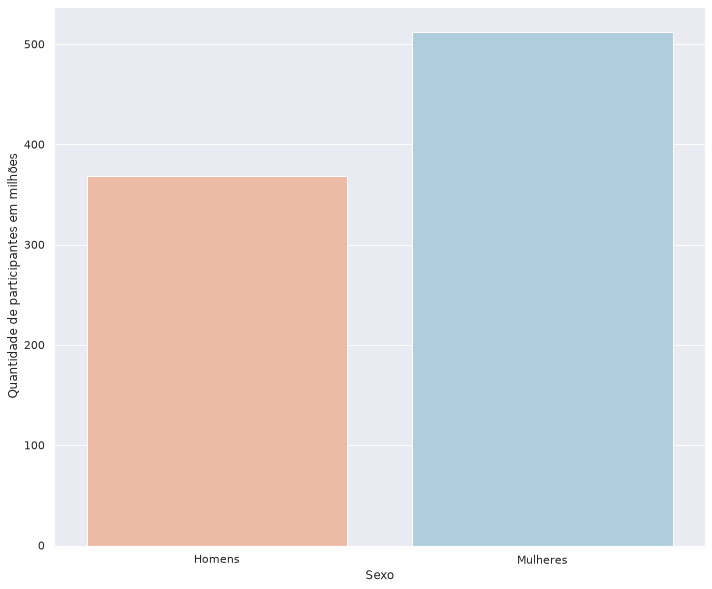

In [109]:
sns.set_theme(
    style='darkgrid',
    # palette='dark',
    rc = {
        'legend.loc': 'upper right',
    }
)
fig, ax = plt.subplots(dpi=70, figsize=(12, 10))

sns.countplot(data=df, x= df["TP_SEXO"].map({"F": "Mulheres", "M": "Homens"}),
             palette="RdBu", ax=ax)

for c in ax.containers:
    for v in c:
        bar_height = v.get_height()
        x_value = v.get_x()
        text = "{:.1%}".format(bar_height/len(df))
ax.set_ylabel("Quantidade de participantes em milhões")
ax.set_xlabel("Sexo")

### Nota média por fatores sociais

/tmp/ipykernel_775506/3239846791.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/3239846791.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/3239846791.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/3239846791.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/3239846791.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/3239846791.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/3239846791.py:8: DeprecationWa

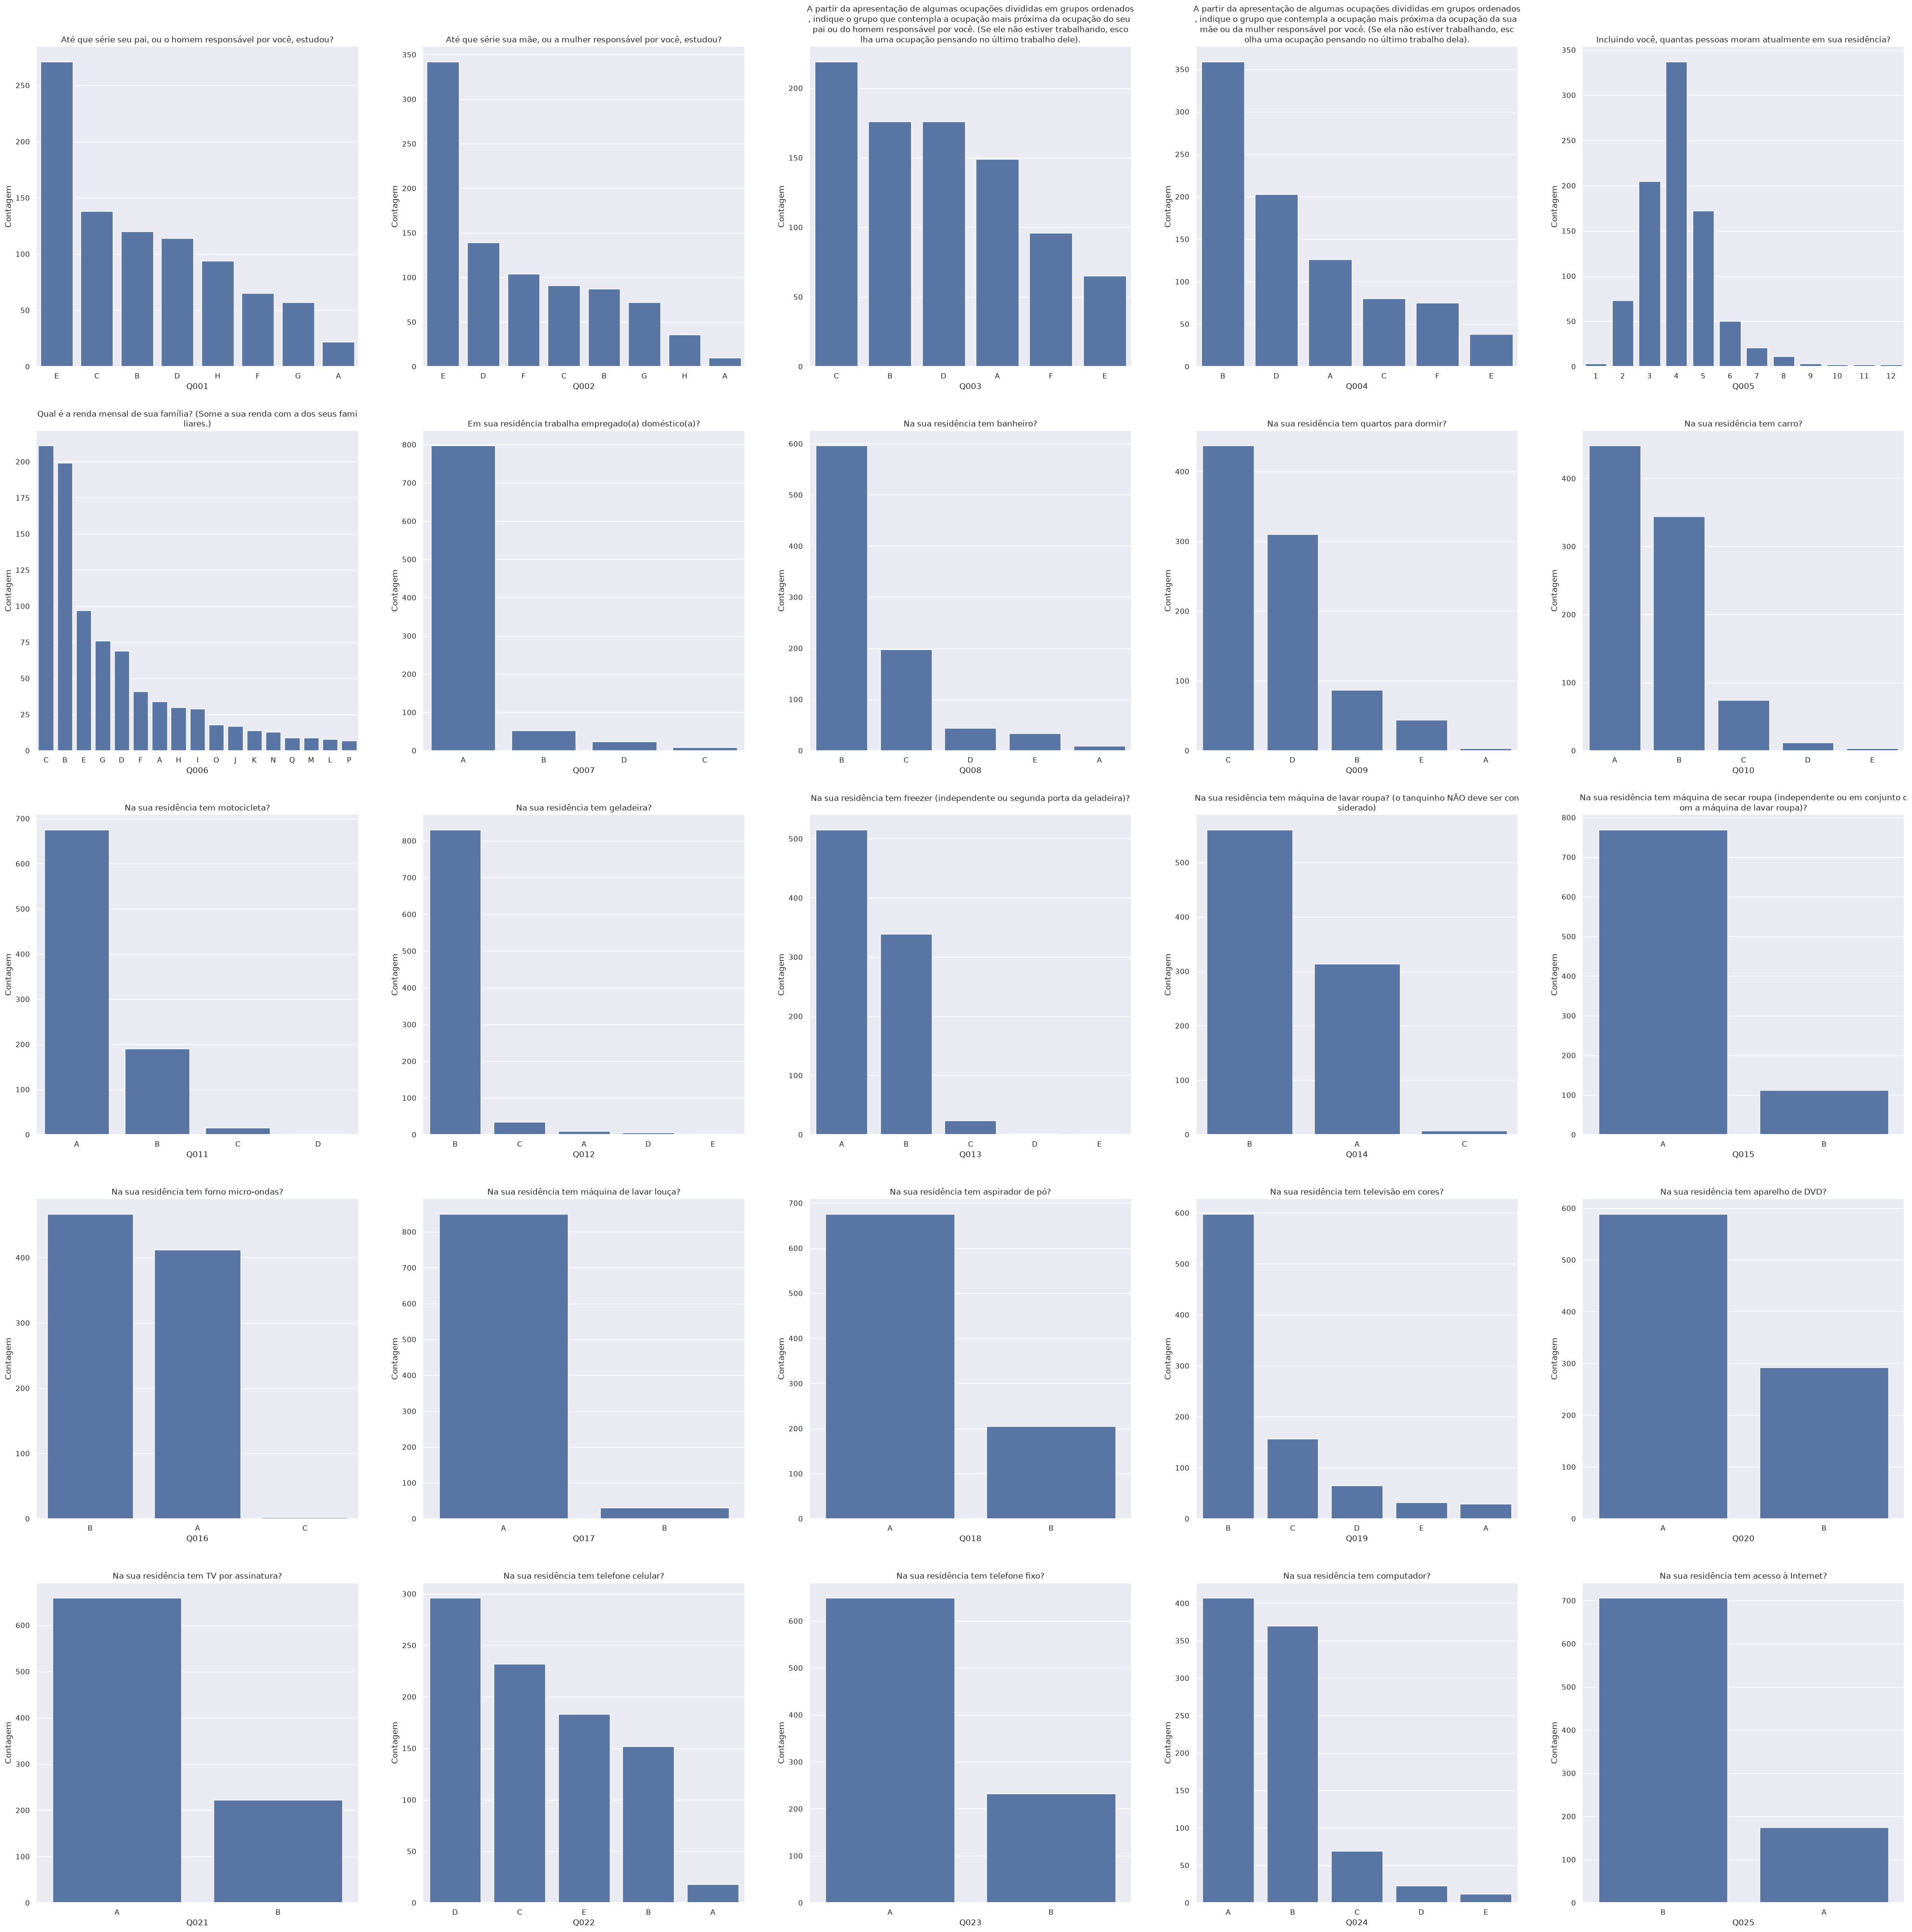

In [110]:
fig = plt.figure(figsize=(50,50))
axs = fig.subplots(5,5)
for ax, column in zip(axs.flat, df.columns[df.columns.str.startswith('Q')]):
    counts = df[column].value_counts().sort_values(ascending=False)
    sns.barplot(x=counts.index, y=counts, ax=ax)
    ax.set_ylabel('Contagem')
    title = descriptions.loc[column, 'Descrição']
    title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
    ax.set_title(title)

### Nota média por sexo, estado civil, raça e etc

/tmp/ipykernel_775506/2558282350.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/2558282350.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/2558282350.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/2558282350.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/2558282350.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/2558282350.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/2558282350.py:8: DeprecationWa

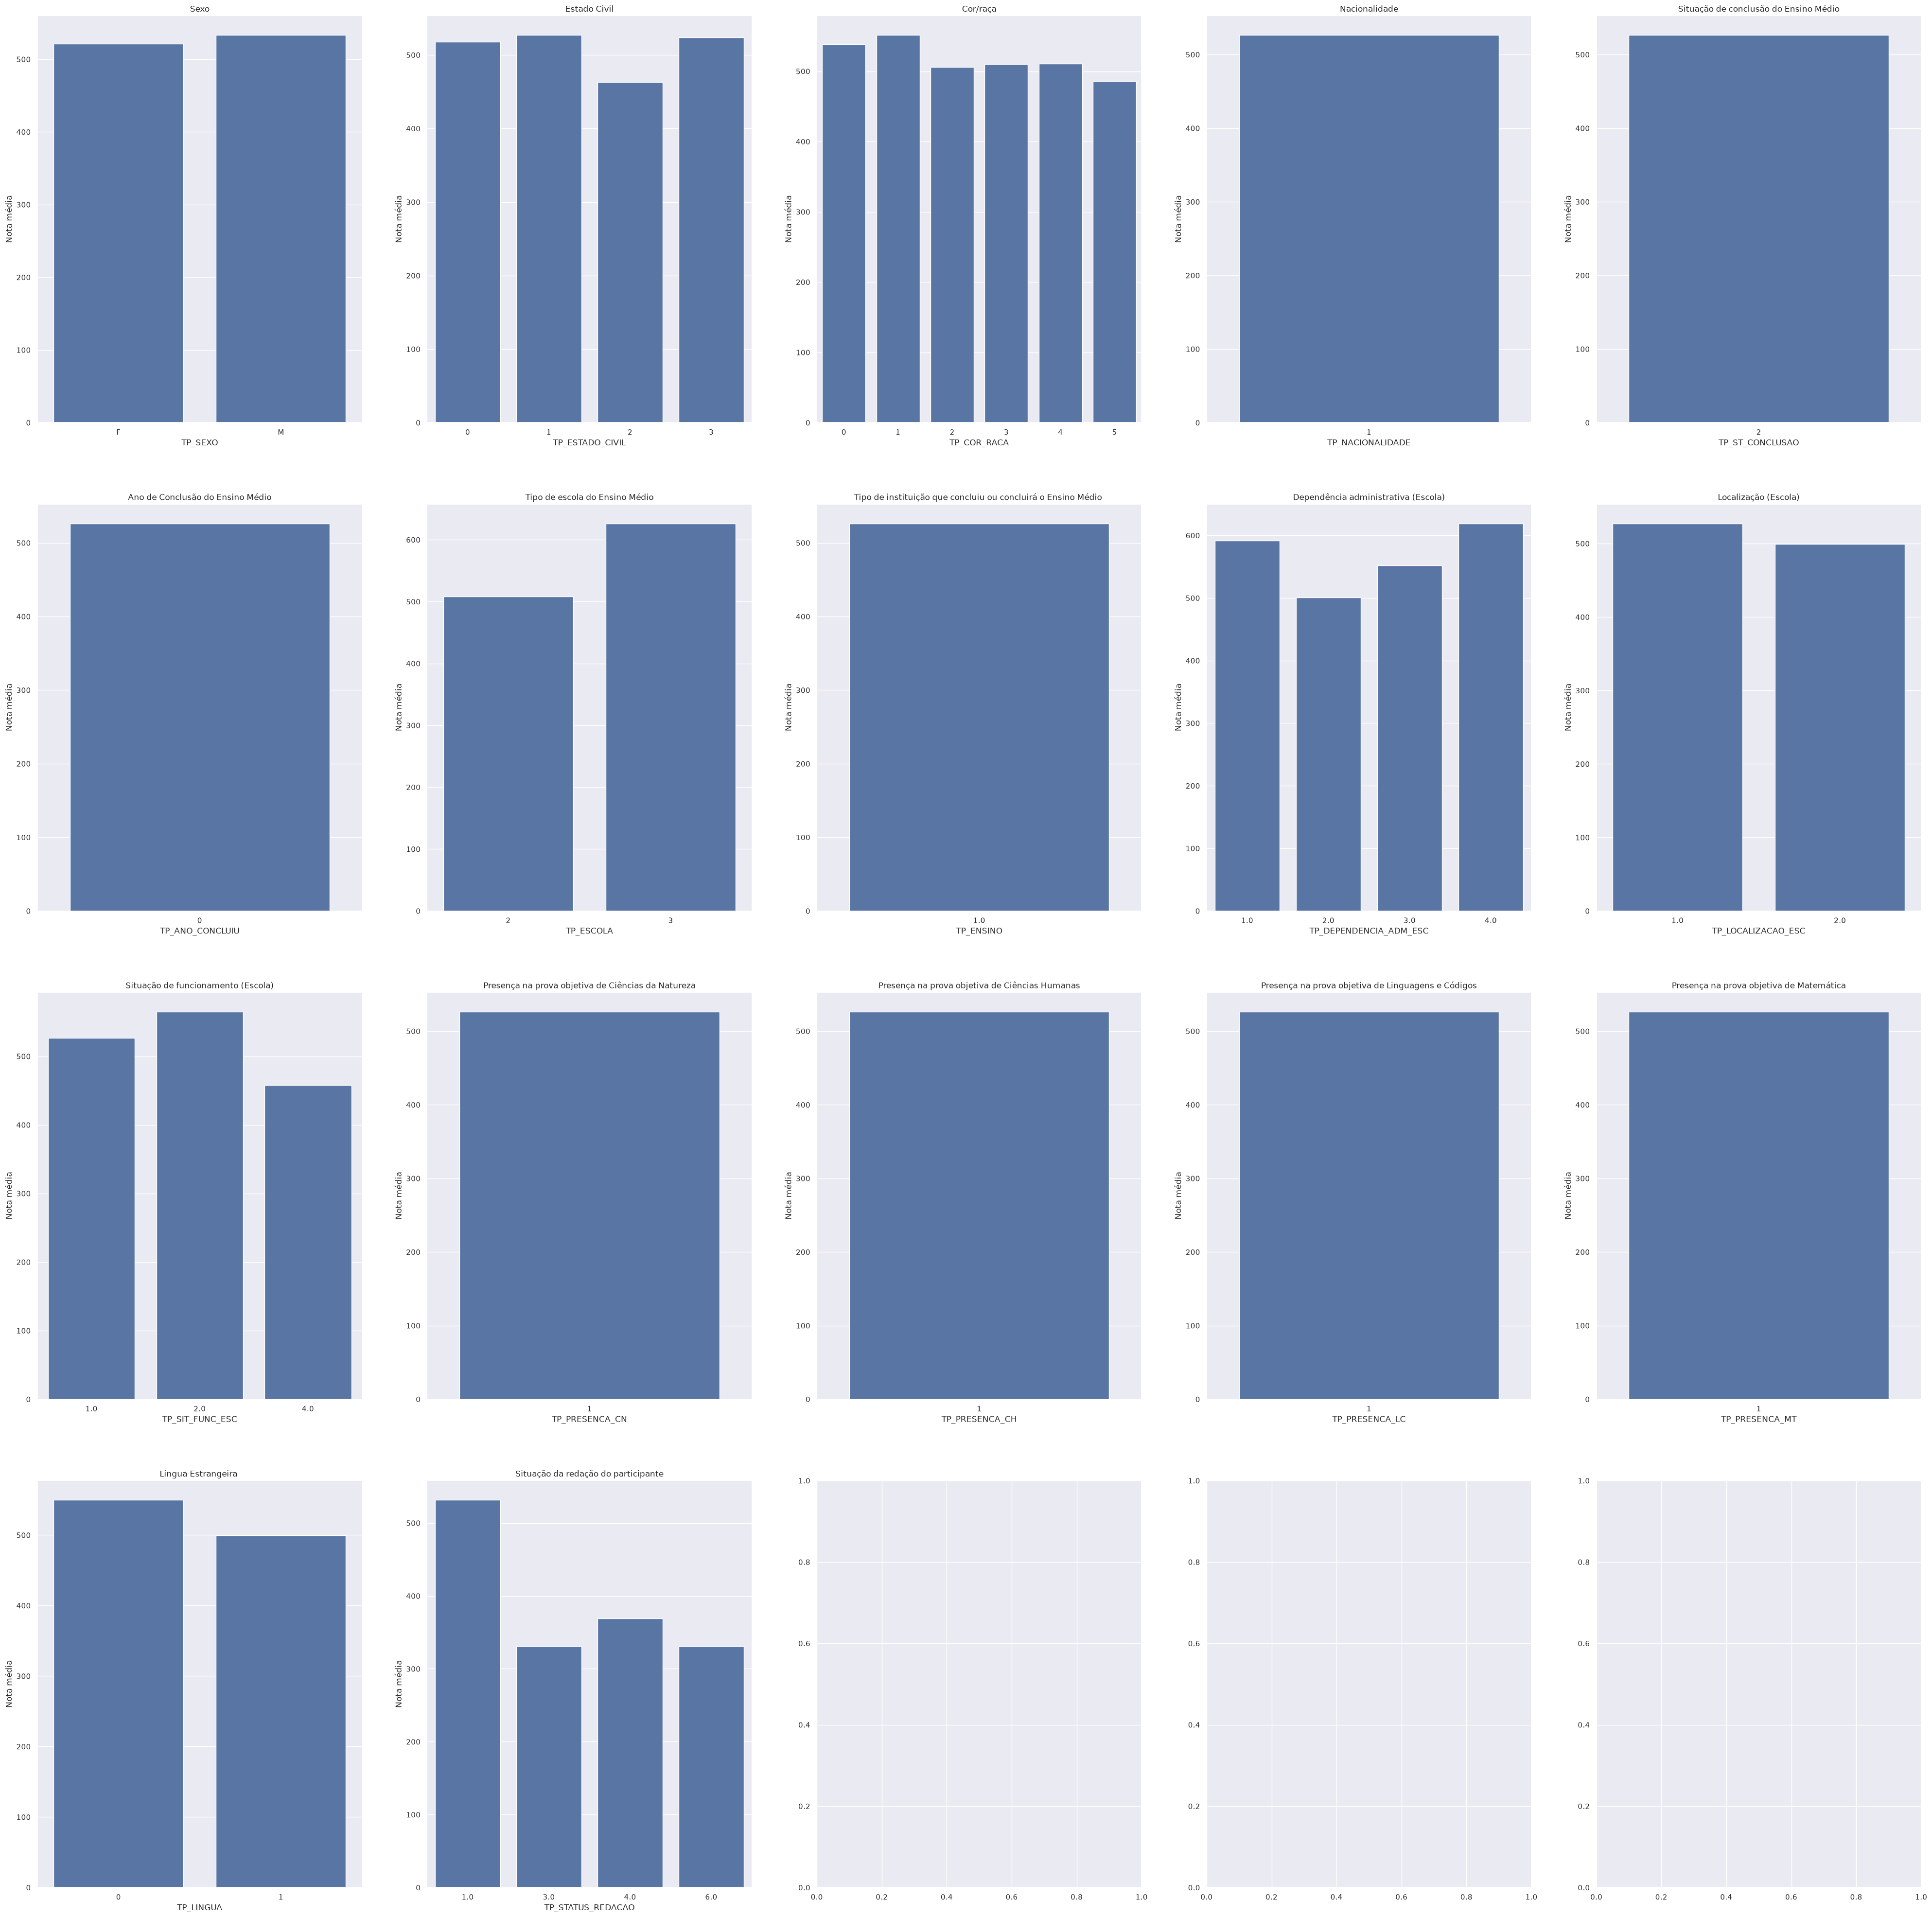

In [111]:
fig = plt.figure(figsize=(50,50))
axs = fig.subplots(4,5)
for ax, column in zip(axs.flat, df.columns[df.columns.str.startswith('TP')]):
    grades = df[[column, *df.columns[df.columns.str.startswith('NU_NOTA')]]].groupby(column).mean().mean(axis=1)
    sns.barplot(x=grades.index, y=grades, ax=ax)
    ax.set_ylabel('Nota média')
    title = descriptions.loc[column, 'Descrição']
    title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
    ax.set_title(title)

### Nota média de treineiro e portadores de condições especiais

/tmp/ipykernel_775506/2255320742.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/2255320742.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/2255320742.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/2255320742.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/2255320742.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/2255320742.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/2255320742.py:8: DeprecationWa

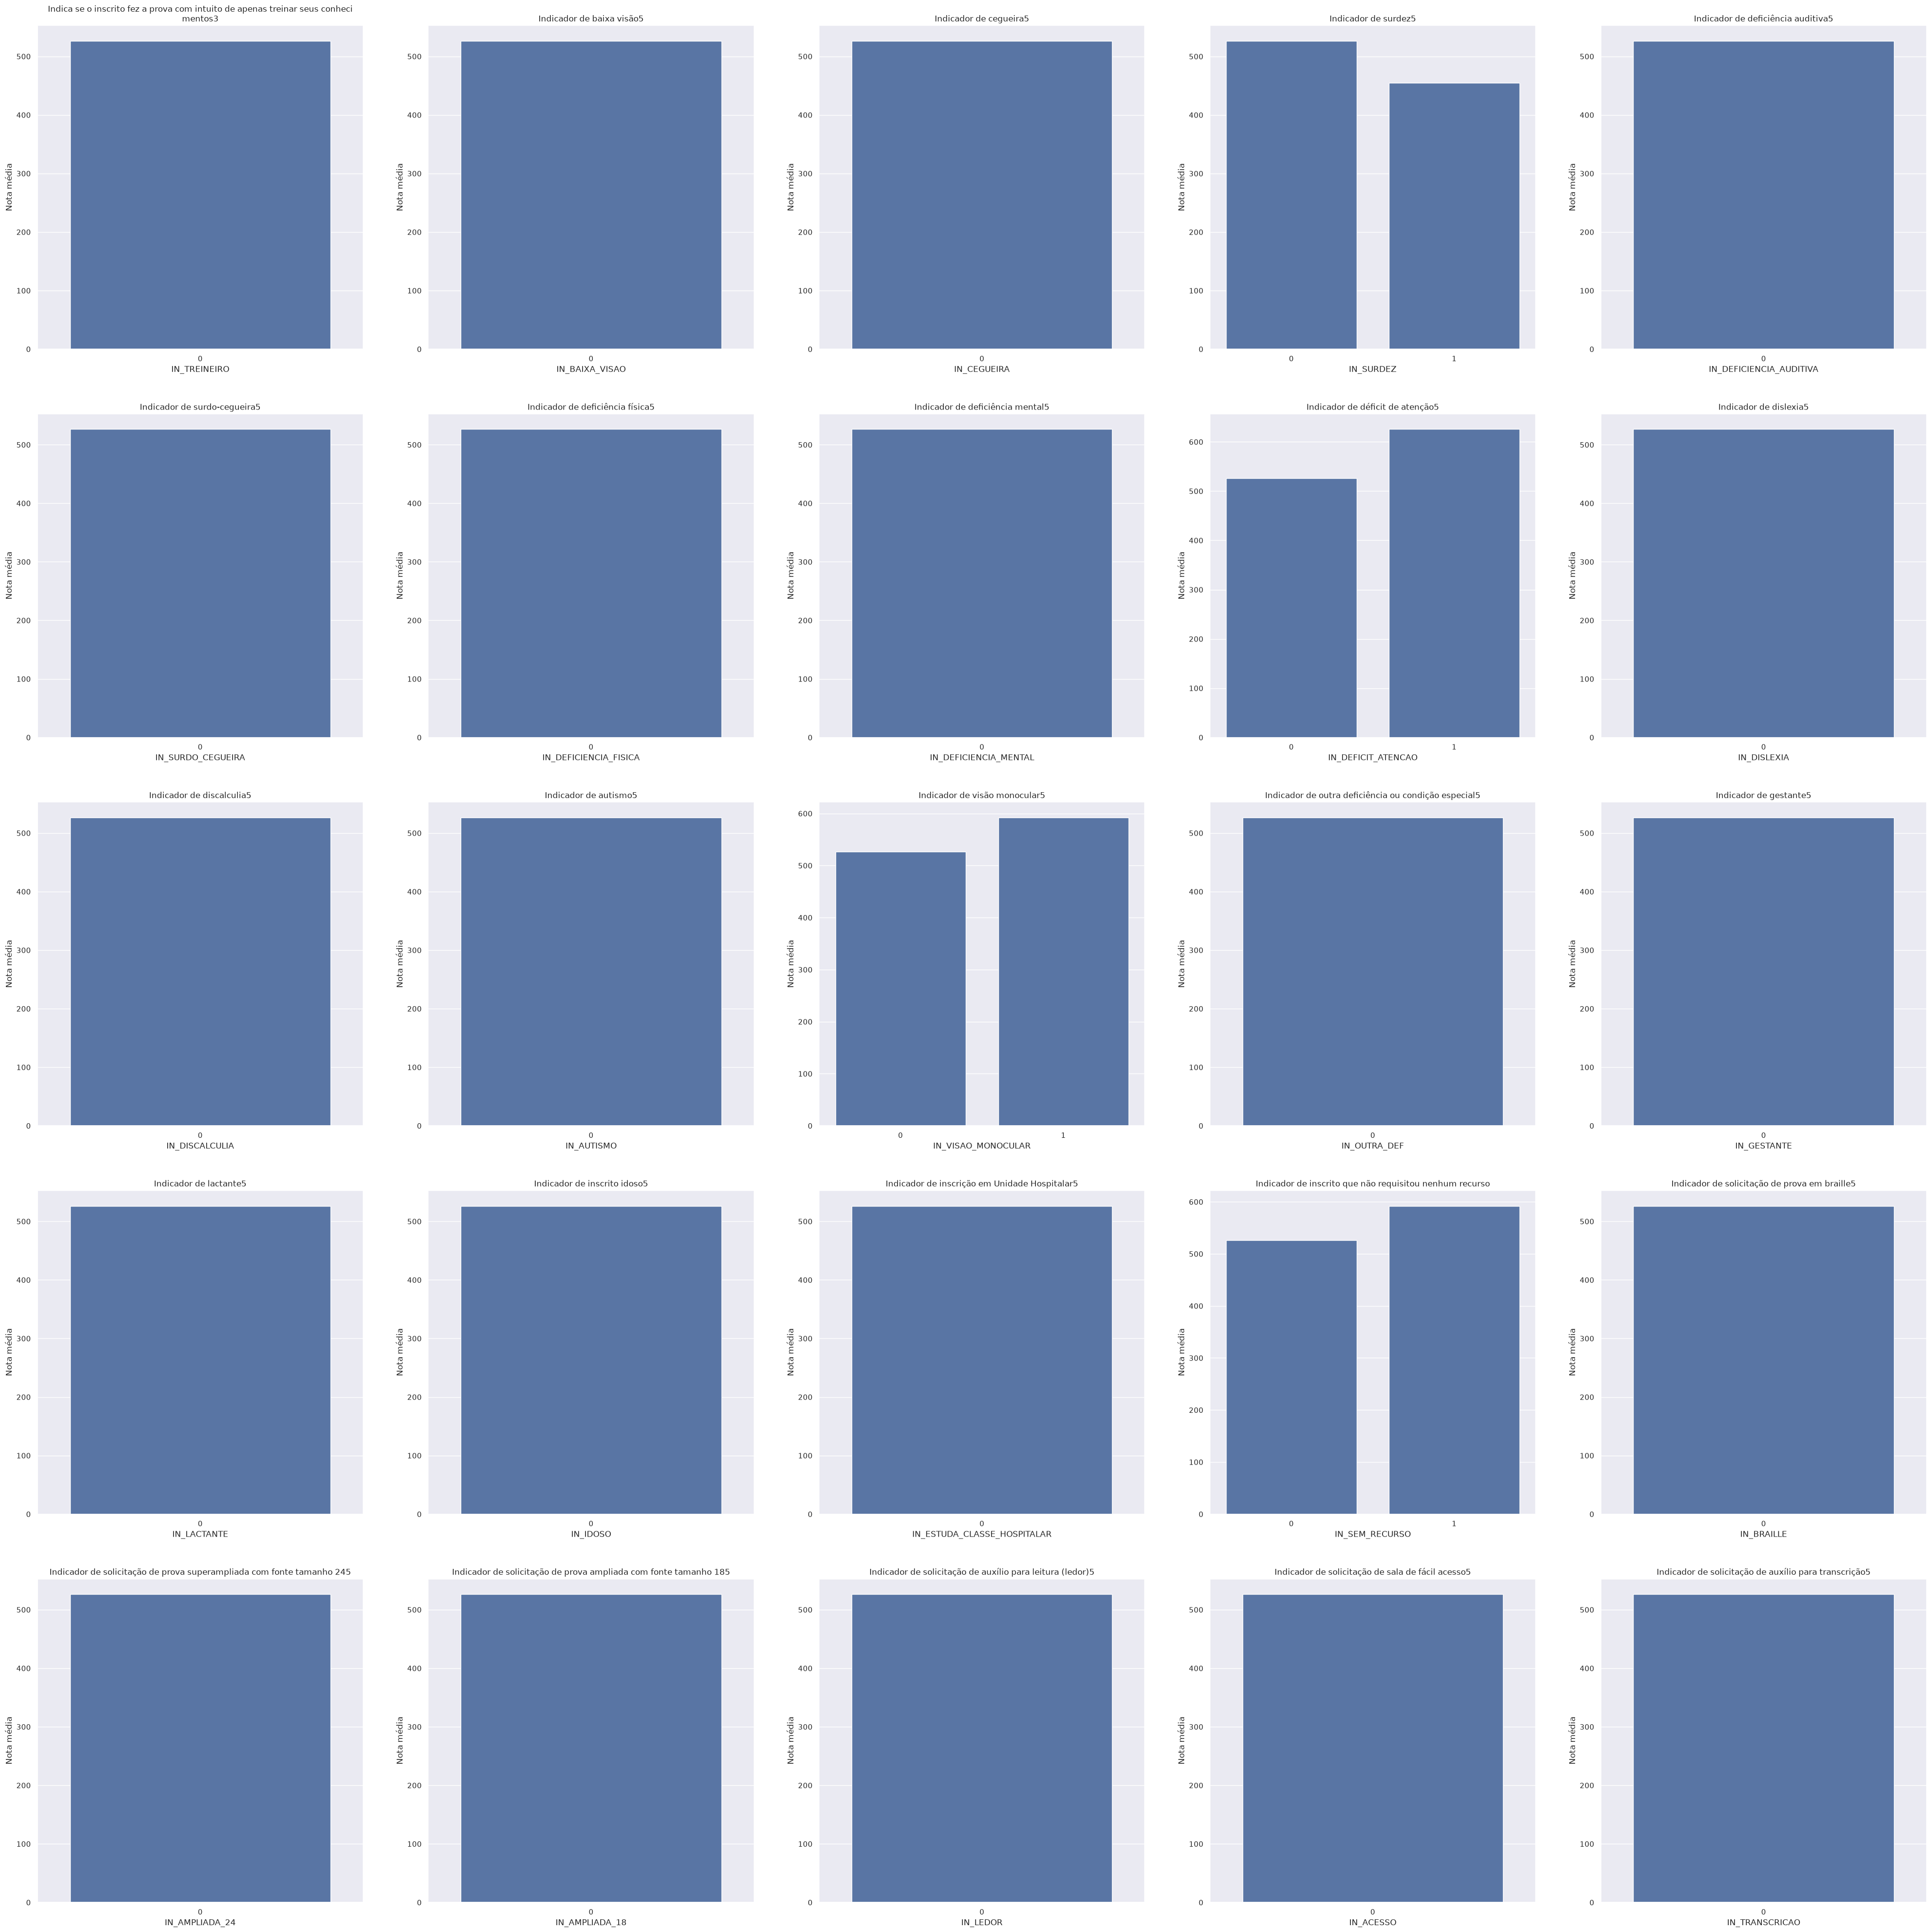

In [112]:
fig = plt.figure(figsize=(50,50))
axs = fig.subplots(5,5)
for ax, column in zip(axs.flat, df.columns[df.columns.str.startswith('IN')]):
    grades = df[[column, *df.columns[df.columns.str.startswith('NU_NOTA')]]].groupby(column).mean().mean(axis=1)
    sns.barplot(x=grades.index, y=grades, ax=ax)
    ax.set_ylabel('Nota média')
    title = descriptions.loc[column, 'Descrição']
    title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
    ax.set_title(title)

### Presença por Condições especiais

/tmp/ipykernel_775506/3575804990.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/3575804990.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/3575804990.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/3575804990.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/3575804990.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/3575804990.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/3575804990.py:8: DeprecationWa

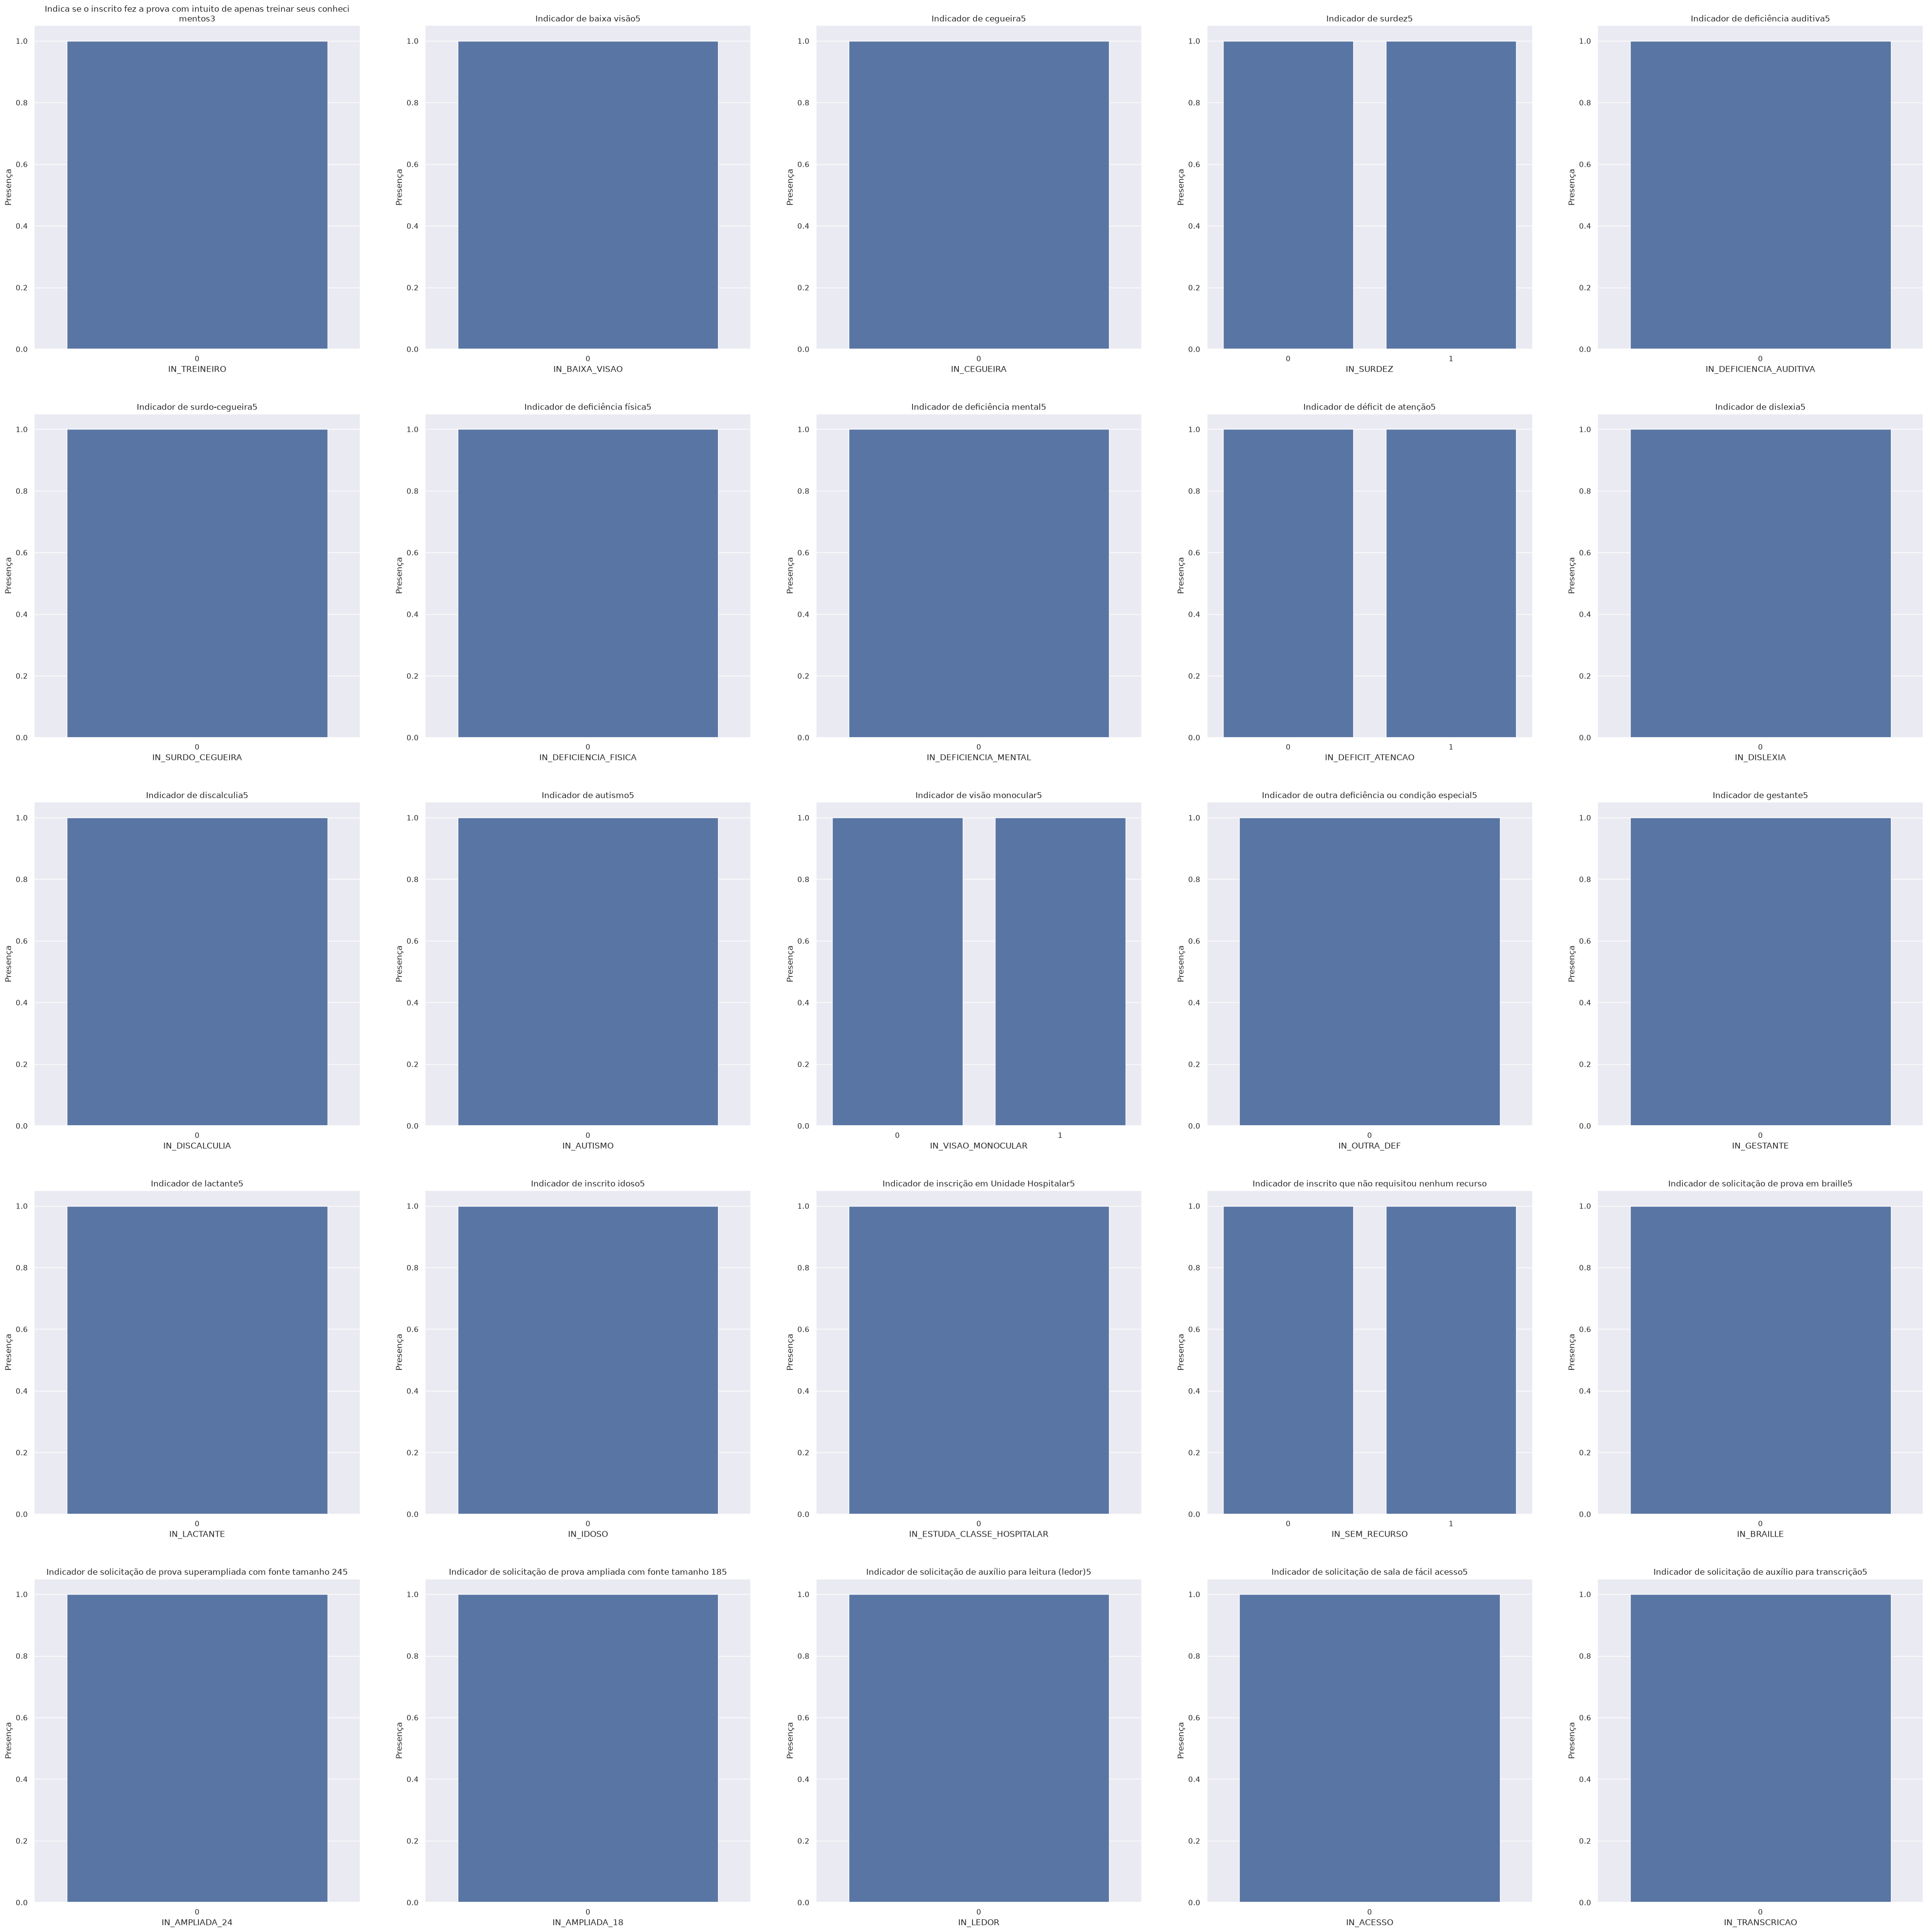

In [113]:
fig = plt.figure(figsize=(50,50))
axs = fig.subplots(5,5)
for ax, column in zip(axs.flat, df.columns[df.columns.str.startswith('IN')]):
    grades = df[[column, *df.columns[df.columns.str.startswith('TP_PRESENCA_CN')]]].groupby(column).mean().mean(axis=1)
    sns.barplot(x=grades.index, y=grades, ax=ax)
    ax.set_ylabel('Presença')
    title = descriptions.loc[column, 'Descrição']
    title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
    ax.set_title(title)

<Axes: xlabel='NU_IDADE', ylabel='nota_Media'>

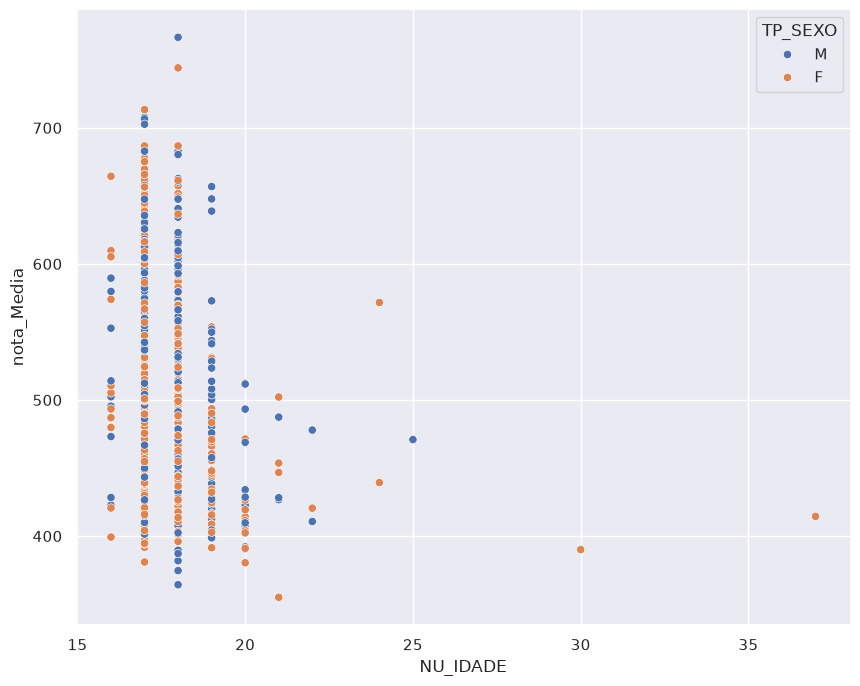

In [114]:
sns.scatterplot(data=df, x="NU_IDADE", y="nota_Media", hue='TP_SEXO')

# TODO

* Plotar relação entre notas e colunas de escola (TP) - Feito
* Ver se os INs relevante a prova (tempo extra por PCD, etc.) não tem relação com a nota - Feito
* Talvez ver se relaçã entre características da pessoa e faltar (mas pensar se não é coincidência porque pode ser) - Feito
* Talvez tirar as pessoas que nao tem presença em alguam prova antes de treinar - Feito
* Plotar nota por prova por questao que começa com Q (gráfico de barras) - Feito

## Modelo de regressão

### EDA

In [115]:
nota_E = df[(df['nota_Media'] > 0) & (df['nota_Media'] <= 200)]
nota_D = df[(df['nota_Media'] > 200) & (df['nota_Media'] <= 400)]
nota_C = df[(df['nota_Media'] > 400) & (df['nota_Media'] <= 600)]
nota_B = df[(df['nota_Media'] > 600) & (df['nota_Media'] <= 800)]
nota_A = df[(df['nota_Media'] > 800) & (df['nota_Media'] <= 1000)]

Text(0.5, 1.0, 'Idade dos participantes do ENEM 2019')

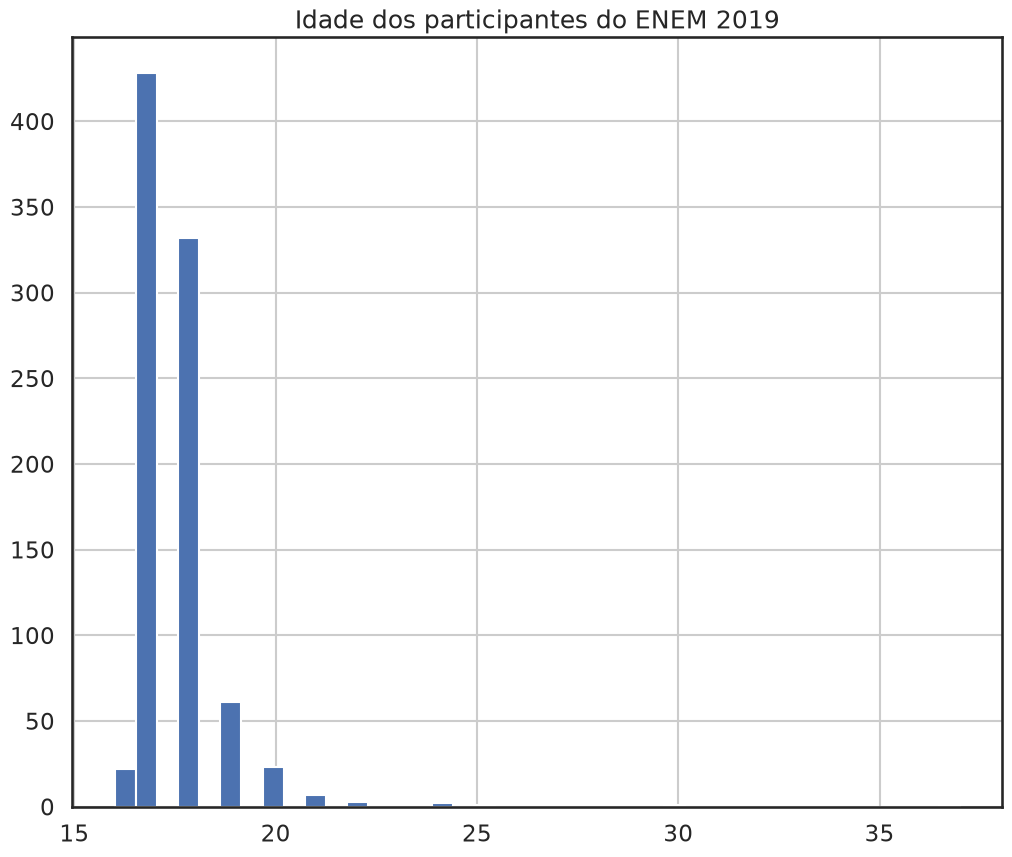

In [116]:
sns.set_theme(style="white", context="talk")
df["NU_IDADE"].hist(bins = 40, figsize = (12,10)).set_title("Idade dos participantes do ENEM 2019")

Text(0.5, 0, 'Etnia')

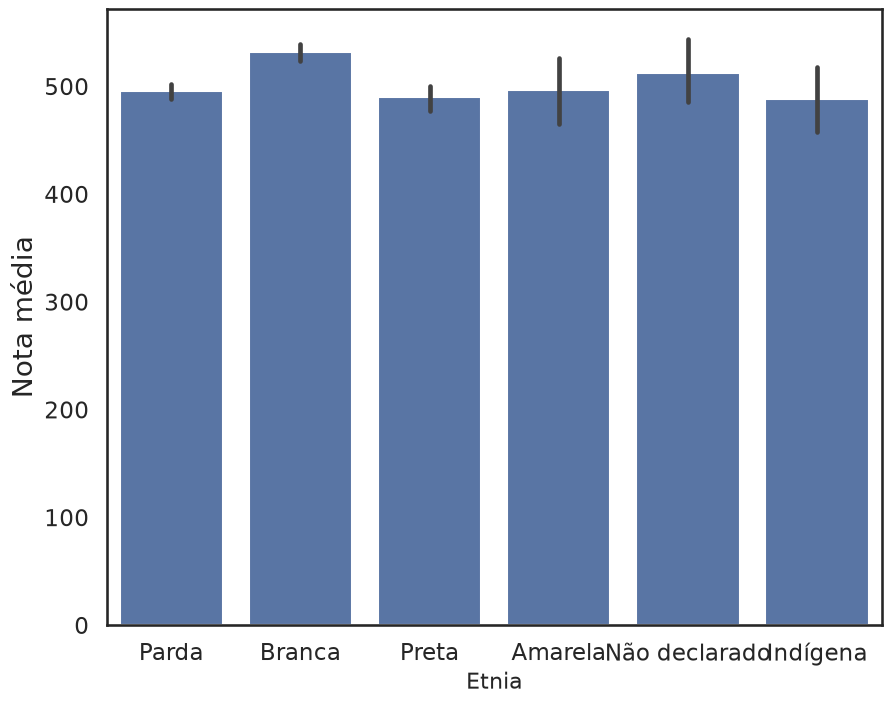

In [117]:
plt.rcParams['figure.figsize'] = (10, 8)
sns.barplot(data=df,
            x = df['TP_COR_RACA'].map({0:'Não declarado',1:'Branca',2:'Preta',3:'Parda',4:'Amarela',5:'Indígena'}), y = df['nota_Media']);
plt.ylabel('Nota média', fontsize=20)
plt.xlabel('Etnia', fontsize=16)

Text(0.5, 0, 'Modalidade')

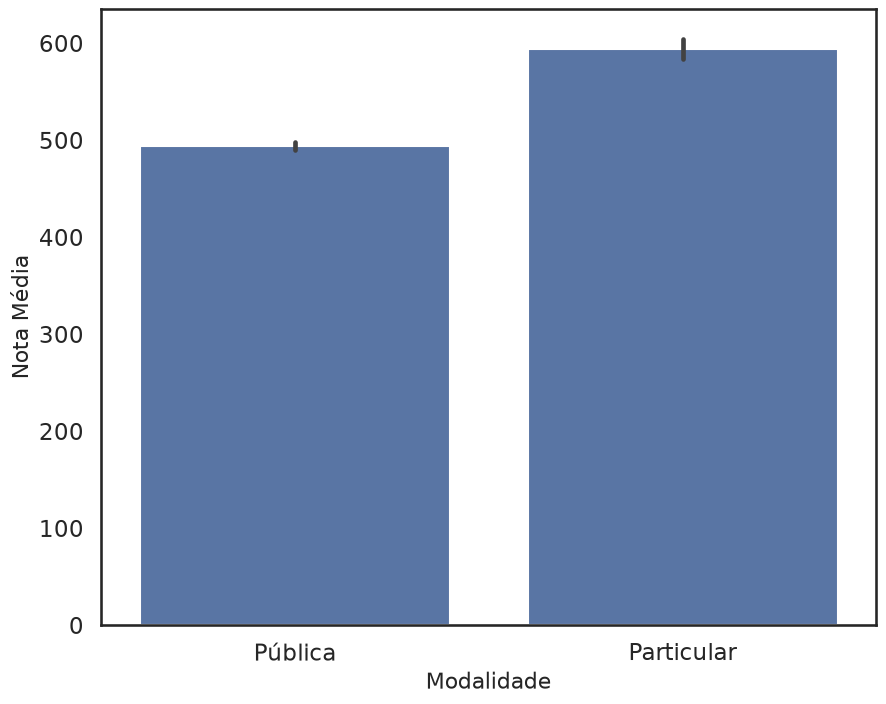

In [118]:
sns.barplot(data=df, x = df['TP_ESCOLA'].map({1:'Não respondeu',2:'Pública',3:'Particular'}), y = df['nota_Media'])
plt.ylabel('Nota Média', fontsize=16)
plt.xlabel('Modalidade', fontsize=16)

/home/gakira/Programming/Python/Enem-2019/enem/lib/python3.13/site-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


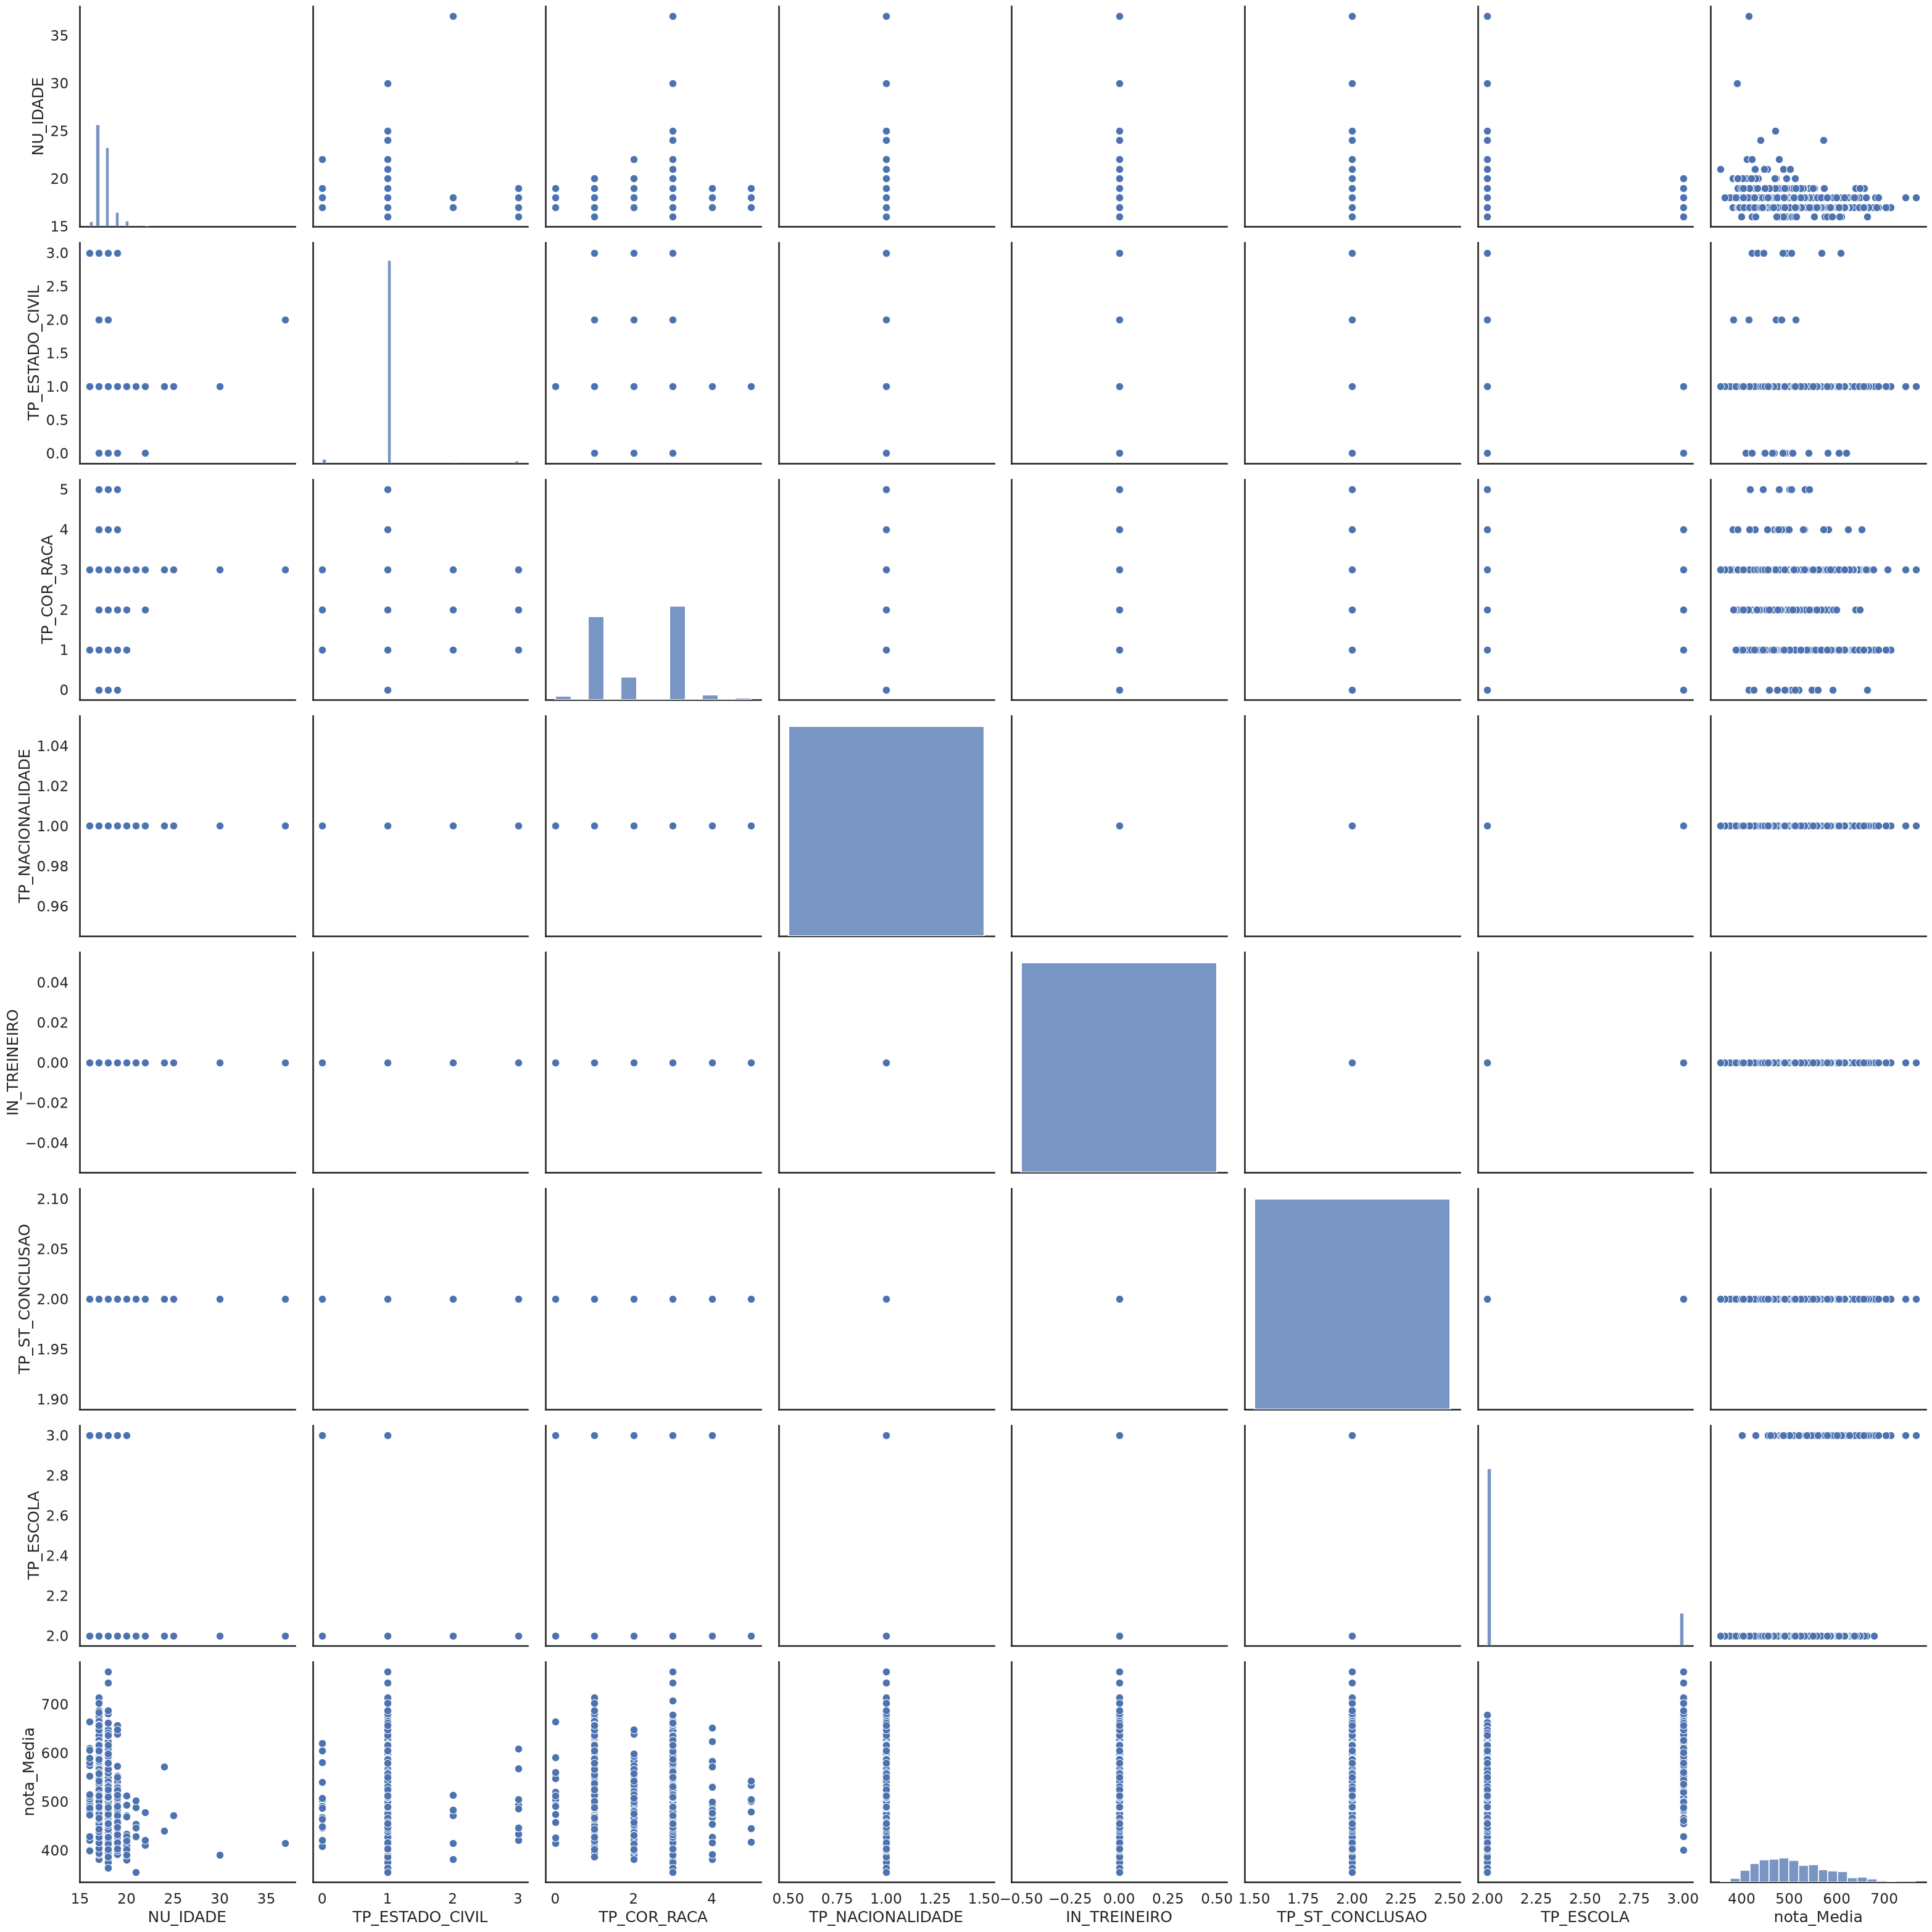

In [119]:
sns.pairplot(data = df[['NU_IDADE', 'TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'IN_TREINEIRO', 'TP_ST_CONCLUSAO', 'TP_ESCOLA', 'nota_Media']], size=4,diag_kind="hist")

Text(0.5, 0, 'Idade')

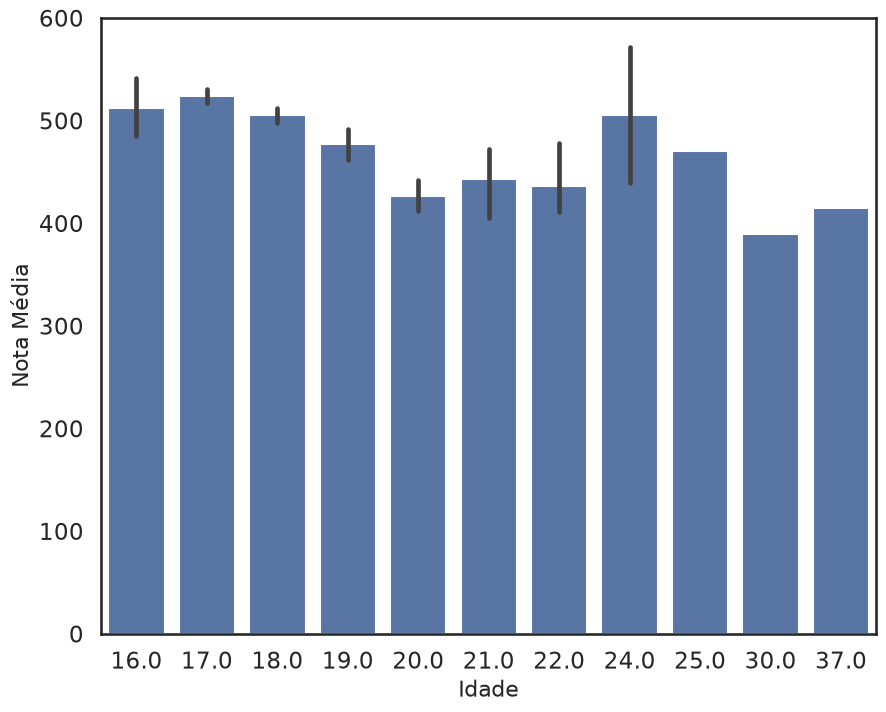

In [120]:
sns.barplot(data=df, x = 'NU_IDADE', y = 'nota_Media')
plt.ylabel('Nota Média', fontsize=16)
plt.xlabel('Idade', fontsize=16)

Text(0.5, 0, 'Estado Civil')

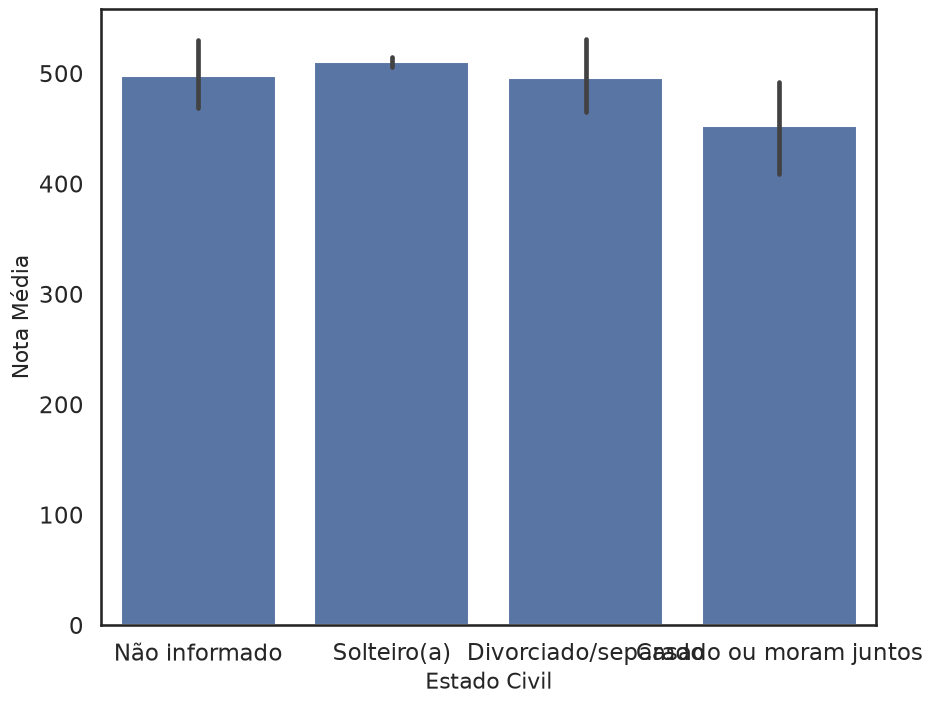

In [121]:
sns.barplot(data=df, x = df['TP_ESTADO_CIVIL'].map({0:'Não informado', 1:'Solteiro(a)', 2:'Casado ou moram juntos', 3:'Divorciado/separado'}), y = 'nota_Media')
plt.ylabel('Nota Média', fontsize=16)
plt.xlabel('Estado Civil', fontsize=16)

Text(0, 0.5, 'Nota Média')

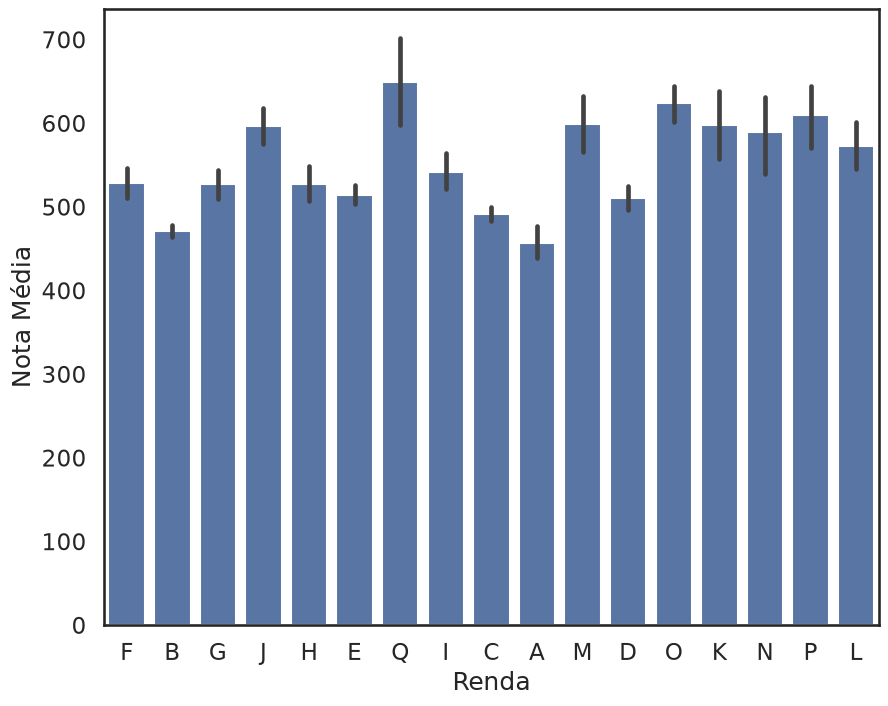

In [122]:
sns.barplot(data=df, x= 'Q006', y = 'nota_Media')
plt.xlabel('Renda')
plt.ylabel('Nota Média')

### Fazer só com as colunas numéricas

In [123]:
### Fazer isso só com as colunas numéricas
#sns.pairplot(dados.iloc[:, :10])

In [124]:
#plt.figure(figsize=(50, 50))
#sns.heatmap(dados.corr(''), annot=True, fmt='.0%')
#IN_SEM_RECURSO

In [125]:
#plt.figure(figsize=(50, 50))
#sns.heatmap(dados.corr(), annot=True, fmt='.0%')

# Treino Modelo 1

In [126]:
train_size = int(len(df)*0.6)
X = df[['NU_IDADE', 'TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO', 'TP_ESCOLA']]
Y = df['nota_Media']

In [127]:
X_train, X_test, y_train, y_test = train_test_split( X, Y, test_size=0.30, random_state=42)

In [128]:
reg = LinearRegression()
modelo1 = reg.fit(X_train, y_train)
y_pred = modelo1.predict(X_test)
reg.coef_

array([-9.09185244,  1.39490969, -7.32158963,  0.        ,  0.        ,
       94.41694562])

Cálculo de erros

In [129]:
#Erro quadrado
mean_squared_error(y_test, y_pred)

3586.6449152020446

In [130]:
#Erro absoluto
mean_absolute_error(y_test, y_pred)

48.67858810051791

In [131]:
#R2 Score
r2 = r2_score(y_test, y_pred)
r2

0.2481137277921991

# Treino Modelo 2

In [132]:
train_size = int(len(df)*0.6)
X = df[['NU_IDADE', 'TP_COR_RACA', 'TP_ST_CONCLUSAO', 'TP_ESCOLA']]
Y = df['nota_Media']

In [133]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.40, random_state=13)

In [134]:
reg = LinearRegression()
modelo2 = reg.fit(X_train, y_train)
y_pred = modelo2.predict(X_test)
reg.coef_

array([-14.68245536,  -4.58720312,   0.        ,  97.78214261])

Cálculo de erros

In [135]:
#Erro quadrado
mean_squared_error(y_test, y_pred)

3486.0986562239536

In [136]:
#Erro absoluto
mean_absolute_error(y_test, y_pred)

47.03898755100987

In [137]:
#R2 Score
r2 = r2_score(y_test, y_pred)
r2

0.2649240623105841

# Treino Modelo 3

In [138]:
train_size = int(len(df)*0.6)
#Q006
X = df[['NU_IDADE', 'TP_COR_RACA', 'IN_TREINEIRO']]
Y = df['nota_Media']

In [139]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.4, random_state=22)

In [140]:
reg = LinearRegression()
modelo3 = reg.fit(X_train, y_train)
y_pred = modelo3.predict(X_test)
reg.coef_

array([-16.87409391, -14.23593302,   0.        ])

Cálculo de erros

In [141]:
#Erro quadrado
mean_squared_error(y_test, y_pred)

4776.440221350757

In [142]:
#Erro absoluto
mean_absolute_error(y_test, y_pred)

56.841925603263654

In [143]:
#R2
r2 = r2_score(y_test, y_pred)
r2

0.06840064907833121

## Análise Exploratória de Dados

In [144]:
#?pd.DataFrame.describe
df.describe

<bound method NDFrame.describe of                               NU_INSCRICAO  CO_MUNICIPIO_RESIDENCIA  \
2     951e80d6-ac9b-4ff2-8130-fcbc8ac78b16                  3139409   
6     cf31ebe2-85d0-4e10-be47-0ea9f49f9242                  2111607   
7     e27bdbb9-e320-476a-ba73-1cdd211c436d                  3132404   
10    e054769b-4932-4df9-bc8e-bd65538a67fb                  2408102   
14    dbd76c6e-2eb0-461a-a13f-4800ad0ea7a5                  3502903   
...                                    ...                      ...   
4987  5945d551-fc4e-44f7-9f86-06d4077a6c61                  2311702   
4989  ece17ba2-7150-48e9-9c45-4c66f3bdf96a                  1600600   
4992  337fa1b9-b011-4237-87fc-17b5d1326e20                  2601102   
4993  d43be82b-42cf-4a5b-a6d6-ab71f5643e62                  2200400   
4996  26b84785-8ac7-4ccd-b7f6-a6dadc10ee56                  3167202   

           NO_MUNICIPIO_RESIDENCIA  CO_UF_RESIDENCIA SG_UF_RESIDENCIA  \
2                         Manhuaçu      

In [145]:
df.info

<bound method DataFrame.info of                               NU_INSCRICAO  CO_MUNICIPIO_RESIDENCIA  \
2     951e80d6-ac9b-4ff2-8130-fcbc8ac78b16                  3139409   
6     cf31ebe2-85d0-4e10-be47-0ea9f49f9242                  2111607   
7     e27bdbb9-e320-476a-ba73-1cdd211c436d                  3132404   
10    e054769b-4932-4df9-bc8e-bd65538a67fb                  2408102   
14    dbd76c6e-2eb0-461a-a13f-4800ad0ea7a5                  3502903   
...                                    ...                      ...   
4987  5945d551-fc4e-44f7-9f86-06d4077a6c61                  2311702   
4989  ece17ba2-7150-48e9-9c45-4c66f3bdf96a                  1600600   
4992  337fa1b9-b011-4237-87fc-17b5d1326e20                  2601102   
4993  d43be82b-42cf-4a5b-a6d6-ab71f5643e62                  2200400   
4996  26b84785-8ac7-4ccd-b7f6-a6dadc10ee56                  3167202   

           NO_MUNICIPIO_RESIDENCIA  CO_UF_RESIDENCIA SG_UF_RESIDENCIA  \
2                         Manhuaçu        

/home/gakira/Programming/Python/Enem-2019/enem/lib/python3.13/site-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


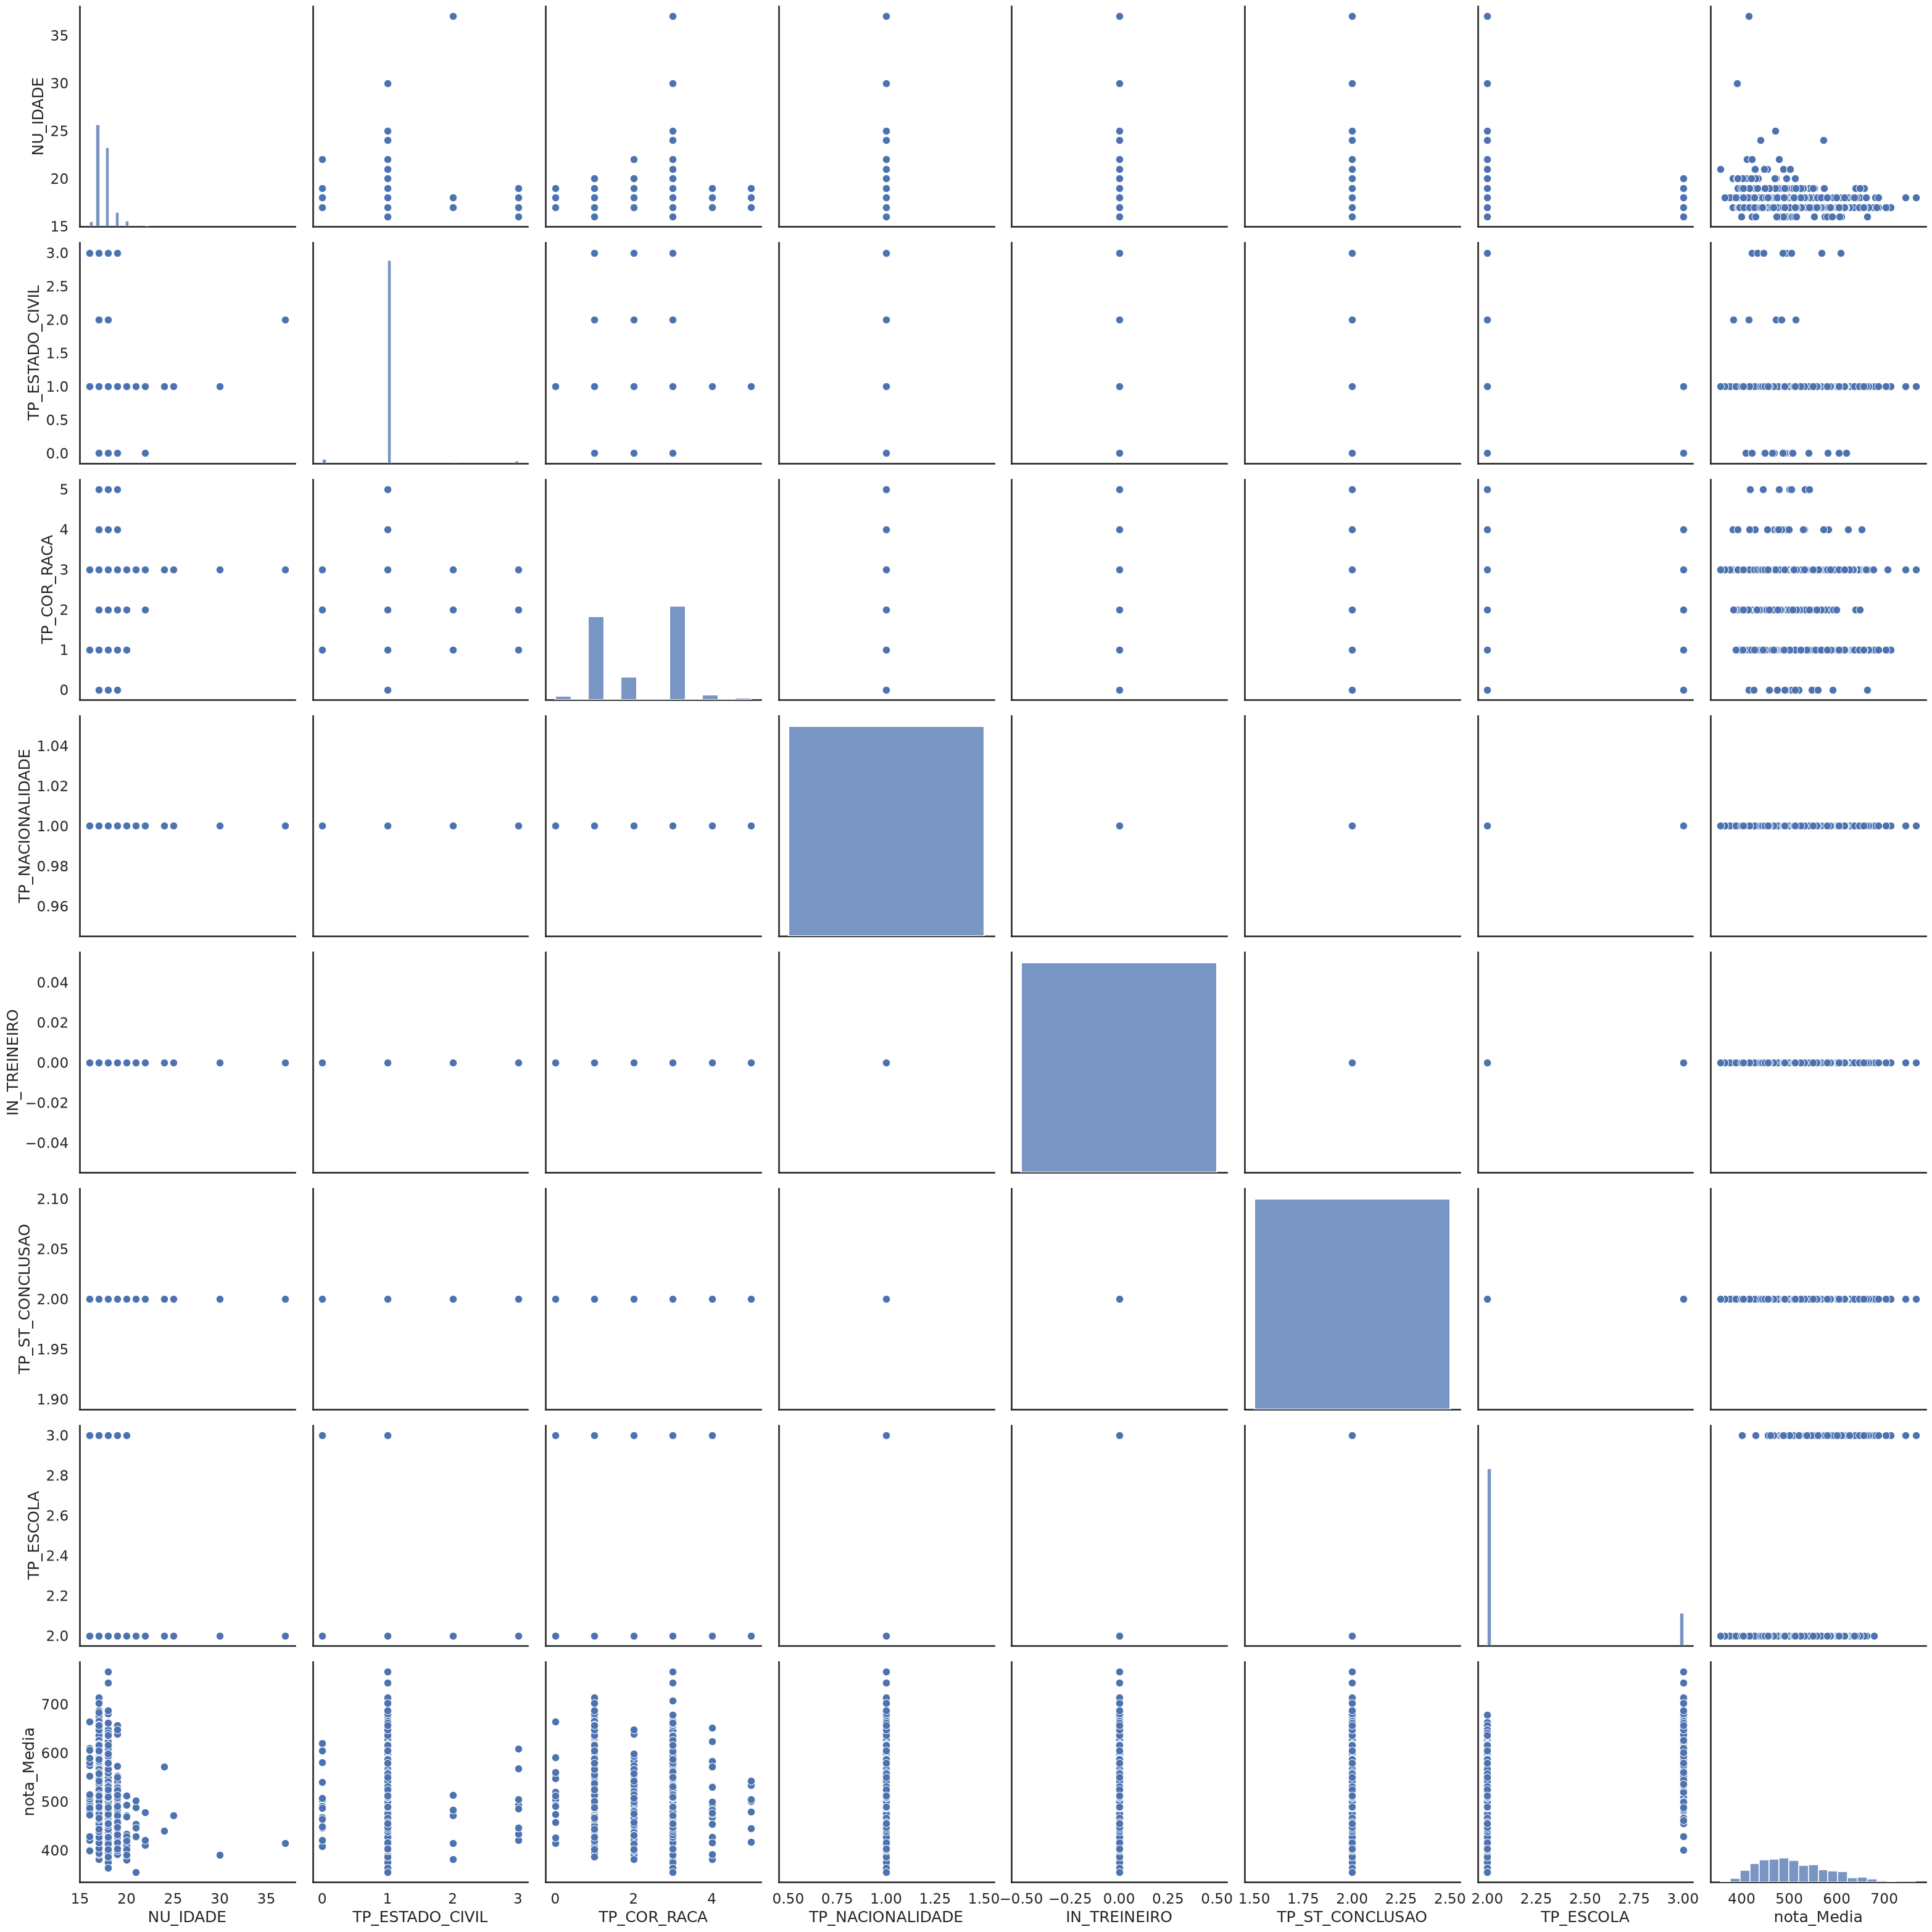

In [146]:
sns.pairplot(data = df[['NU_IDADE', 'TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'IN_TREINEIRO', 'TP_ST_CONCLUSAO', 'TP_ESCOLA', 'nota_Media']], size=4,diag_kind="hist")

In [147]:
#One hot
#Pairplot com barra

## Treino de modelo

### Regressão Linear